In [1]:
# Check GPU availability
!nvidia-smi

Sat Sep 26 23:49:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install Ultralytics (YOLOv8)
!pip install -q ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 11.6 MB/s eta 0:00:00


In [3]:
# Verify Ultralytics installation
import ultralytics
from ultralytics import YOLO

ultralytics.checks()

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


In [4]:
# Download the frozen YOLOv8 dataset from GitHub Release
DATASET_URL = "https://github.com/MohamedElsayed356/construction-site-object-detection-yolov8/releases/download/dataset-v1.0/Construction.Site.Object.Detecti.v1i.yolov8.zip"

!wget -q --show-progress "$DATASET_URL" -O dataset.zip

print("Dataset downloaded successfully.")

dataset.zip         100%[===================>]  25.57M  9.65MB/s    in 2.6s    
Dataset downloaded successfully.


In [5]:
# Extract the frozen dataset
import os
import zipfile

DATASET_DIR = "/content/dataset"

os.makedirs(DATASET_DIR, exist_ok=True)

with zipfile.ZipFile("/content/dataset.zip", "r") as zip_ref:
    zip_ref.extractall(DATASET_DIR)

print("Dataset extracted successfully.\n")

# Display dataset structure
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, "").count(os.sep)
    if level <= 2:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")
        for file in files[:10]:
            print(f"{indent}    {file}")

Dataset extracted successfully.

dataset/
    README.roboflow.txt
    README.dataset.txt
    data.yaml
    valid/
        labels/
            WhatsApp-Image-2026-09-26-at-09-07-50-1-_jpeg.rf.22e4adc81100e9453fc3a644d5c7feb8.txt
            WhatsApp-Image-2026-09-26-at-08-30-24-1-_jpeg.rf.d39921cc5e61cc0530c4f00b1b0d4aa4.txt
            WhatsApp-Image-2026-09-26-at-08-30-17-2-_jpeg.rf.81a0774a3e0b75904b08b7b8370b9d15.txt
            WhatsApp-Image-2026-09-26-at-08-30-21-5-_jpeg.rf.e3627144bb07f8a5c9789059b79b10ba.txt
            WhatsApp-Image-2026-09-26-at-08-30-24_jpeg.rf.8f7130fe393ecc04d999e260c0062061.txt
            WhatsApp-Image-2026-09-26-at-08-30-22-1-_jpeg.rf.8bc925652b802b0e8b50efa3c3fbc595.txt
            WhatsApp-Image-2026-09-26-at-08-30-26-1-_jpeg.rf.72b6e94bd9540ed29db74dc7c9ee01cd.txt
            WhatsApp-Image-2026-09-26-at-08-30-12-2-_jpeg.rf.65bb69a0b28530381244a5b8ec9997e6.txt
            WhatsApp-Image-2026-09-26-at-08-29-57_jpeg.rf.ba3c3bedae4183132ab0eb4a33aeb13

In [6]:
# Inspect data.yaml and verify dataset counts
import os
import yaml

YAML_PATH = "/content/dataset/data.yaml"

with open(YAML_PATH, "r") as f:
    data_config = yaml.safe_load(f)

print("===== data.yaml =====")
print(data_config)

print("\n===== Dataset Counts =====")

for split in ["train", "valid"]:
    images_dir = f"/content/dataset/{split}/images"
    labels_dir = f"/content/dataset/{split}/labels"

    image_count = len([
        f for f in os.listdir(images_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    label_count = len([
        f for f in os.listdir(labels_dir)
        if f.lower().endswith(".txt")
    ])

    print(f"{split.upper():5} -> Images: {image_count} | Labels: {label_count}")

===== data.yaml =====
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 4, 'names': ['excavator', 'grader', 'truck', 'worker'], 'roboflow': {'workspace': 'keshta_mido2000-yahoo-com', 'project': 'construction-site-object-detecti-l8wfp', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/keshta_mido2000-yahoo-com/construction-site-object-detecti-l8wfp/dataset/1'}}

===== Dataset Counts =====
TRAIN -> Images: 330 | Labels: 330
VALID -> Images: 28 | Labels: 28


In [7]:
# Fix data.yaml paths for Google Colab

import yaml

YAML_PATH = "/content/dataset/data.yaml"

with open(YAML_PATH, "r") as f:
    data = yaml.safe_load(f)

# Set absolute paths
data["train"] = "/content/dataset/train/images"
data["val"] = "/content/dataset/valid/images"

# No test split exists in this frozen dataset
data.pop("test", None)

with open(YAML_PATH, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("Updated data.yaml:\n")

with open(YAML_PATH, "r") as f:
    print(f.read())

Updated data.yaml:

train: /content/dataset/train/images
val: /content/dataset/valid/images
nc: 4
names:
- excavator
- grader
- truck
- worker
roboflow:
  workspace: keshta_mido2000-yahoo-com
  project: construction-site-object-detecti-l8wfp
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/keshta_mido2000-yahoo-com/construction-site-object-detecti-l8wfp/dataset/1



In [8]:
# Dataset integrity check before training

import os
from collections import Counter

dataset_root = "/content/dataset"
class_names = ["excavator", "grader", "truck", "worker"]

for split in ["train", "valid"]:

    images_dir = os.path.join(dataset_root, split, "images")
    labels_dir = os.path.join(dataset_root, split, "labels")

    image_files = [
        f for f in os.listdir(images_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    label_files = [
        f for f in os.listdir(labels_dir)
        if f.endswith(".txt")
    ]

    missing_labels = []
    class_counter = Counter()
    invalid_classes = []

    for image in image_files:

        base = os.path.splitext(image)[0]
        label_path = os.path.join(labels_dir, base + ".txt")

        if not os.path.exists(label_path):
            missing_labels.append(image)
            continue

        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if not parts:
                    continue

                class_id = int(float(parts[0]))

                if 0 <= class_id < len(class_names):
                    class_counter[class_names[class_id]] += 1
                else:
                    invalid_classes.append(class_id)

    print(f"\n===== {split.upper()} =====")
    print("Images:", len(image_files))
    print("Labels:", len(label_files))
    print("Missing labels:", len(missing_labels))
    print("Invalid class IDs:", len(invalid_classes))
    print("Object annotations:")

    for name in class_names:
        print(f"  {name}: {class_counter[name]}")

print("\nDataset integrity check completed.")


===== TRAIN =====
Images: 330
Labels: 330
Missing labels: 0
Invalid class IDs: 0
Object annotations:
  excavator: 513
  grader: 54
  truck: 160
  worker: 1778

===== VALID =====
Images: 28
Labels: 28
Missing labels: 0
Invalid class IDs: 0
Object annotations:
  excavator: 59
  grader: 0
  truck: 0
  worker: 76

Dataset integrity check completed.


In [9]:
# Load pretrained YOLOv8 model

from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8n pretrained model loaded successfully.")

YOLOv8n pretrained model loaded successfully.


In [10]:
# Train YOLOv8 model on the construction-site dataset

results = model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/runs",
    name="construction_yolov8n",
    pretrained=True,
    patience=15,
    save=True,
    plots=True,
    verbose=True
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=construction_yolov8n, nbs=64, nms=None, opset=Non

Training curves found successfully:


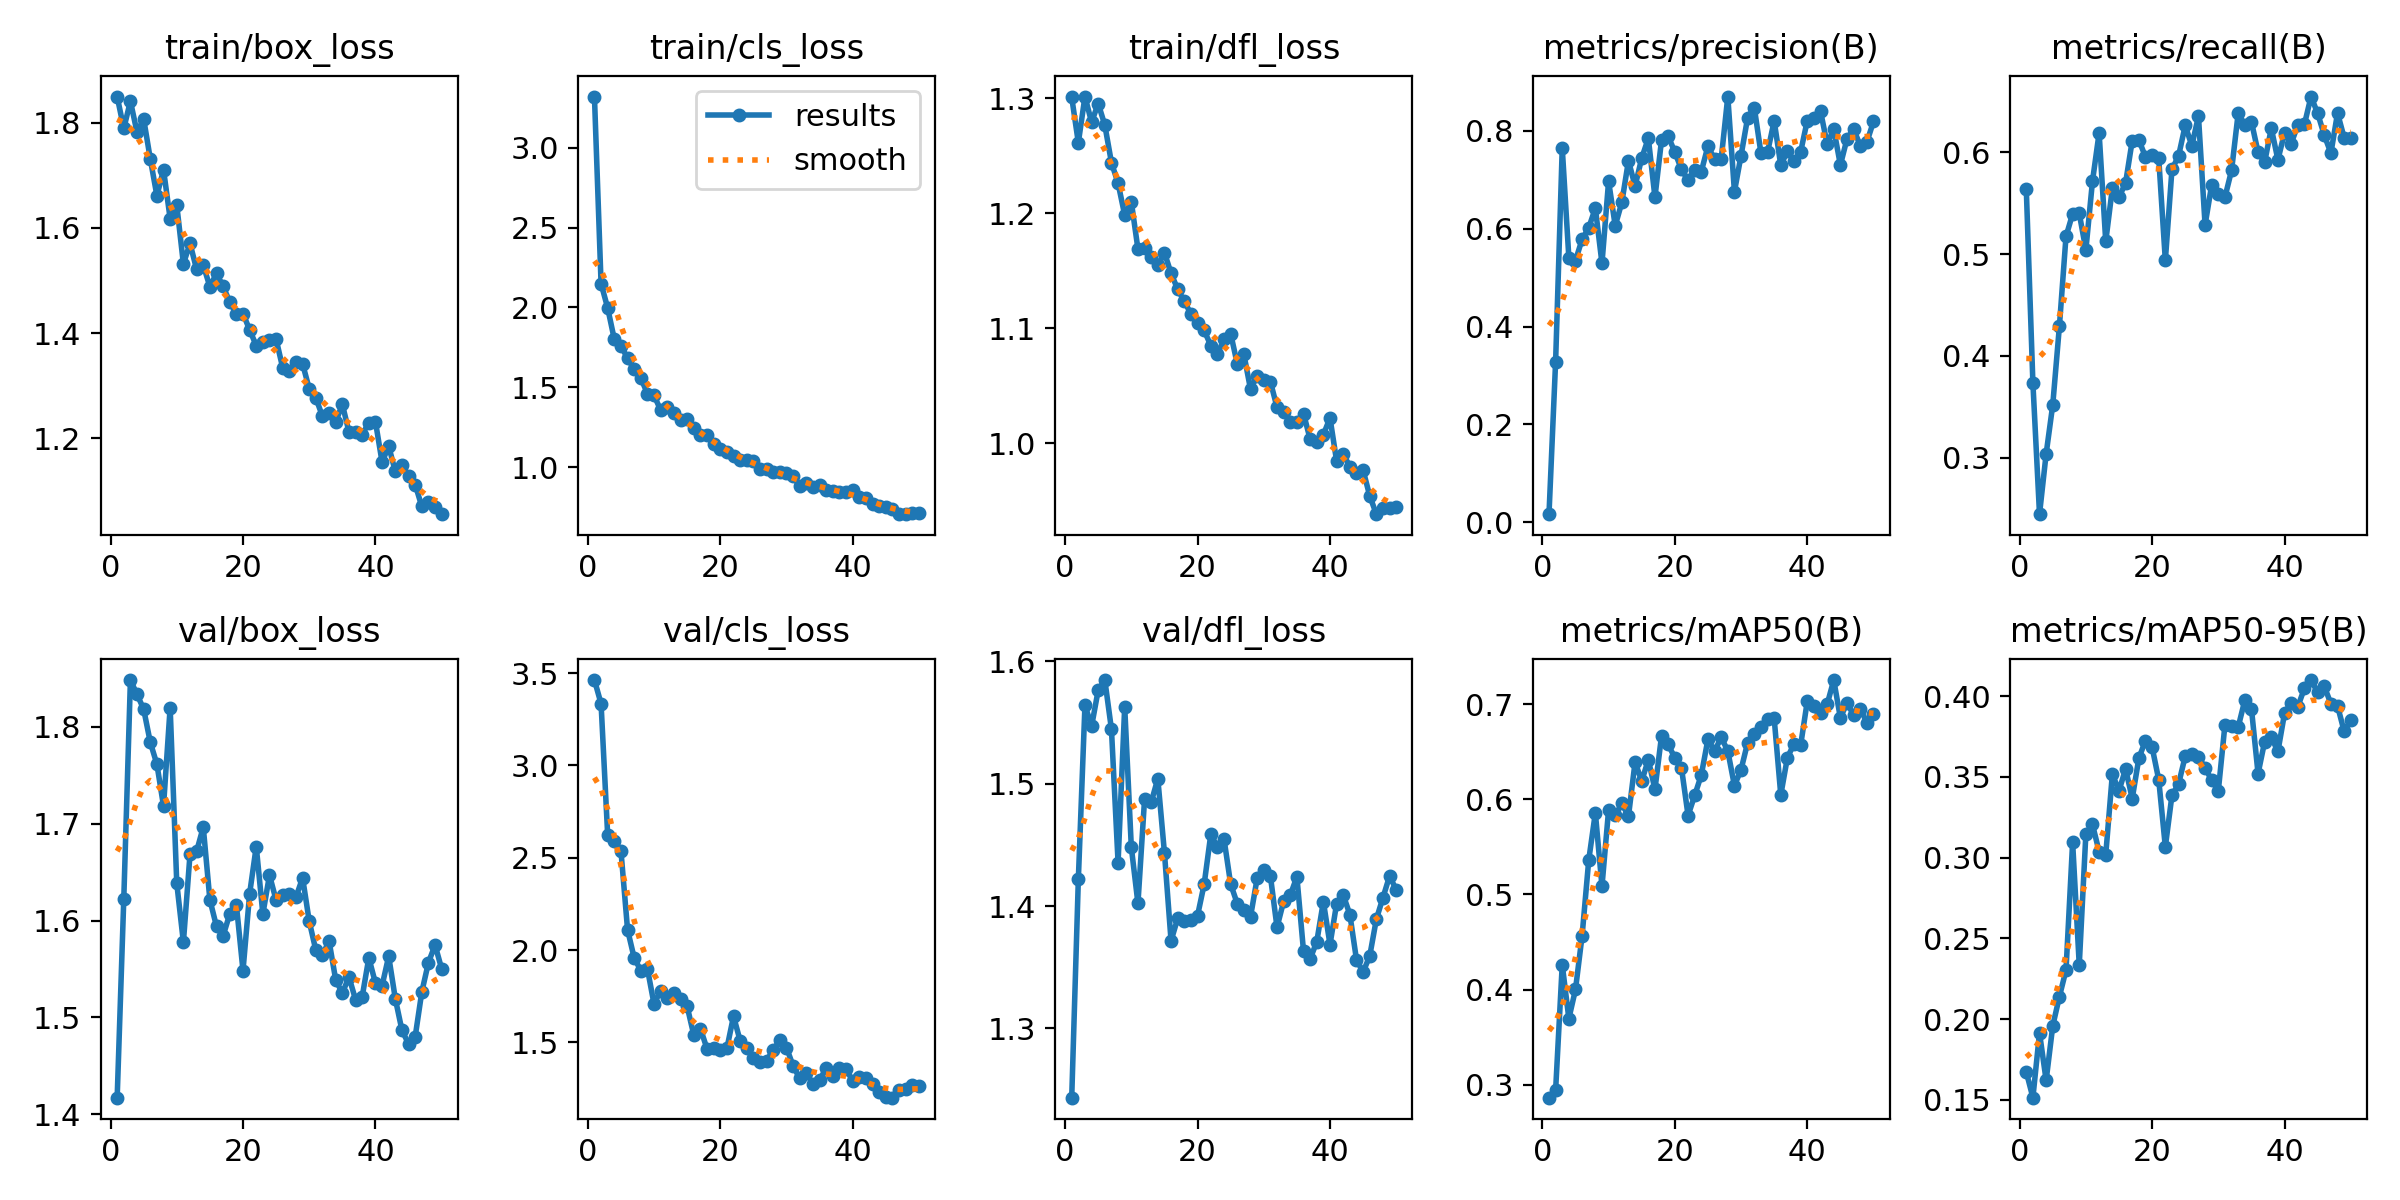


Training artifacts:
- BoxF1_curve.png
- BoxPR_curve.png
- BoxP_curve.png
- BoxR_curve.png
- args.yaml
- confusion_matrix.png
- confusion_matrix_normalized.png
- labels.jpg
- results.csv
- results.png
- train_batch0.jpg
- train_batch1.jpg
- train_batch2.jpg
- train_batch840.jpg
- train_batch841.jpg
- train_batch842.jpg
- val_batch0_labels.jpg
- val_batch0_pred.jpg
- weights


In [11]:
# Cell 11 - Display training results and curves

from IPython.display import Image, display
import os

RUN_DIR = "/content/runs/construction_yolov8n"

results_png = os.path.join(RUN_DIR, "results.png")

if os.path.exists(results_png):
    print("Training curves found successfully:")
    display(Image(filename=results_png, width=1000))
else:
    print("results.png was not found.")

print("\nTraining artifacts:")
for file in sorted(os.listdir(RUN_DIR)):
    print("-", file)


image 1/28 /content/dataset/valid/images/WhatsApp-Image-2026-09-26-at-08-29-57_jpeg.rf.ba3c3bedae4183132ab0eb4a33aeb13b.jpg: 640x640 8 workers, 9.9ms
image 2/28 /content/dataset/valid/images/WhatsApp-Image-2026-09-26-at-08-30-05_jpeg.rf.c933cd49d9d6507f6808327642ff1e67.jpg: 640x640 6 workers, 14.6ms
image 3/28 /content/dataset/valid/images/WhatsApp-Image-2026-09-26-at-08-30-11-1-_jpeg.rf.e28fb99f199b39a4b557d87951b979a0.jpg: 640x640 4 workers, 11.9ms
image 4/28 /content/dataset/valid/images/WhatsApp-Image-2026-09-26-at-08-30-12-2-_jpeg.rf.65bb69a0b28530381244a5b8ec9997e6.jpg: 640x640 3 excavators, 10.9ms
image 5/28 /content/dataset/valid/images/WhatsApp-Image-2026-09-26-at-08-30-13-1-_jpeg.rf.c94faa87be2fe7803e5b8f2309432418.jpg: 640x640 10 excavators, 7.4ms
image 6/28 /content/dataset/valid/images/WhatsApp-Image-2026-09-26-at-08-30-14-3-_jpeg.rf.d6eb544aa2cdf5e620a07d2268e9540e.jpg: 640x640 3 excavators, 1 grader, 7.4ms
image 7/28 /content/dataset/valid/images/WhatsApp-Image-2026-09-

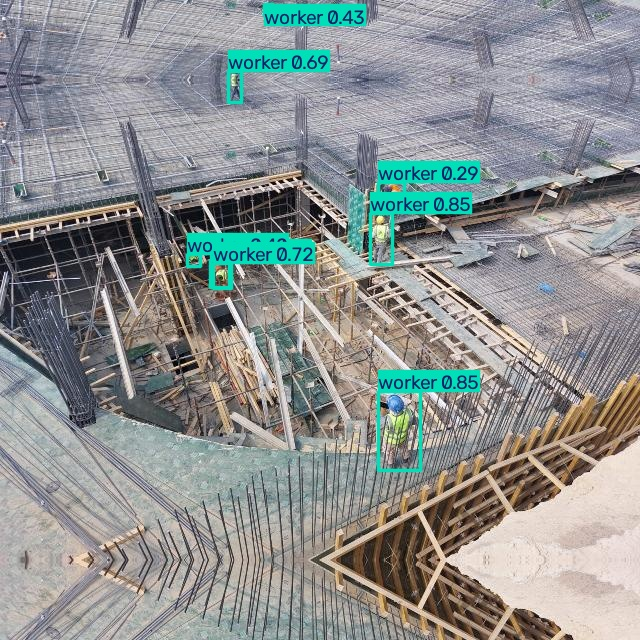


 WhatsApp-Image-2026-09-26-at-08-30-05_jpeg.rf.c933cd49d9d6507f6808327642ff1e67.jpg


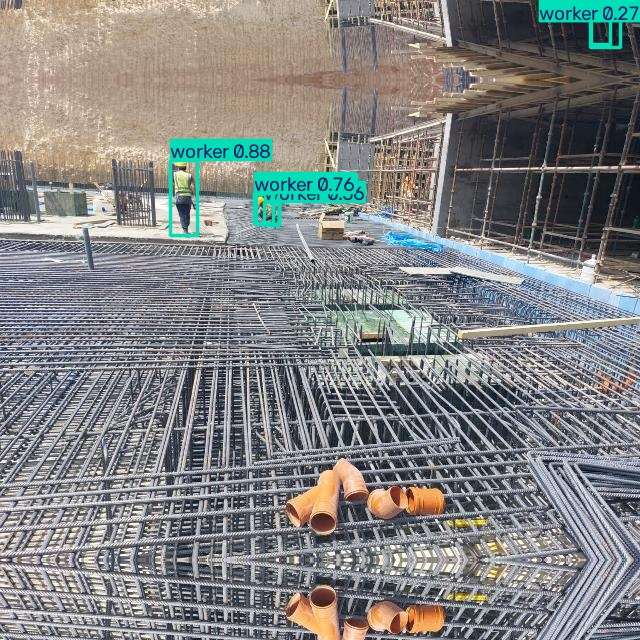


 WhatsApp-Image-2026-09-26-at-08-30-11-1-_jpeg.rf.e28fb99f199b39a4b557d87951b979a0.jpg


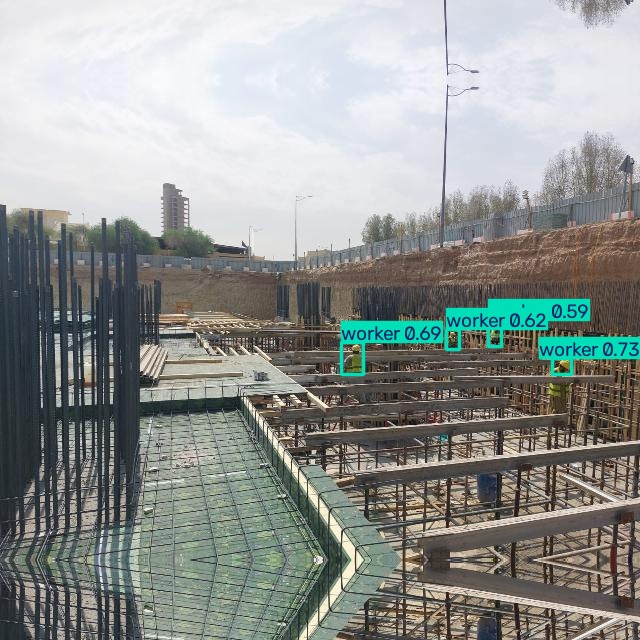


 WhatsApp-Image-2026-09-26-at-08-30-12-2-_jpeg.rf.65bb69a0b28530381244a5b8ec9997e6.jpg


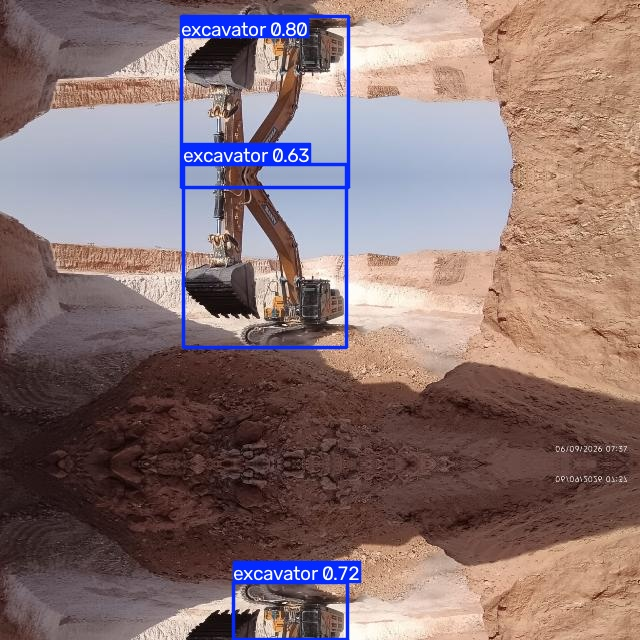


 WhatsApp-Image-2026-09-26-at-08-30-13-1-_jpeg.rf.c94faa87be2fe7803e5b8f2309432418.jpg


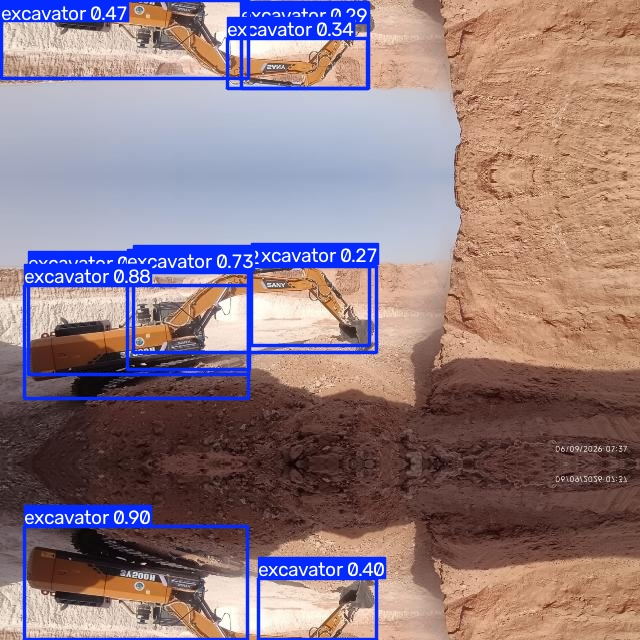


 WhatsApp-Image-2026-09-26-at-08-30-14-3-_jpeg.rf.d6eb544aa2cdf5e620a07d2268e9540e.jpg


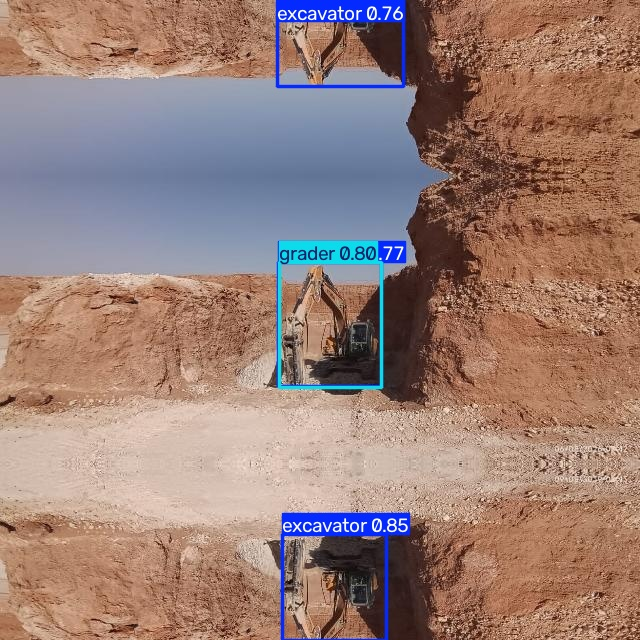

In [12]:
# Cell 12 - Validation inference using the best trained model

from ultralytics import YOLO
from IPython.display import Image, display
import glob
import os

BEST_MODEL = "/content/runs/construction_yolov8n/weights/best.pt"
VAL_IMAGES = "/content/dataset/valid/images"

# Load the best trained weights
best_model = YOLO(BEST_MODEL)

# Run inference on validation images
predictions = best_model.predict(
    source=VAL_IMAGES,
    imgsz=640,
    conf=0.25,
    save=True,
    project="/content/inference",
    name="validation",
    exist_ok=True
)

print(f"\nValidation inference completed on {len(predictions)} images.")

# Display a sample of prediction results
prediction_files = sorted(
    glob.glob("/content/inference/validation/*.jpg") +
    glob.glob("/content/inference/validation/*.jpeg") +
    glob.glob("/content/inference/validation/*.png")
)

print(f"Saved prediction images: {len(prediction_files)}")

for img_path in prediction_files[:6]:
    print("\n", os.path.basename(img_path))
    display(Image(filename=img_path, width=750))


===== confusion_matrix.png =====


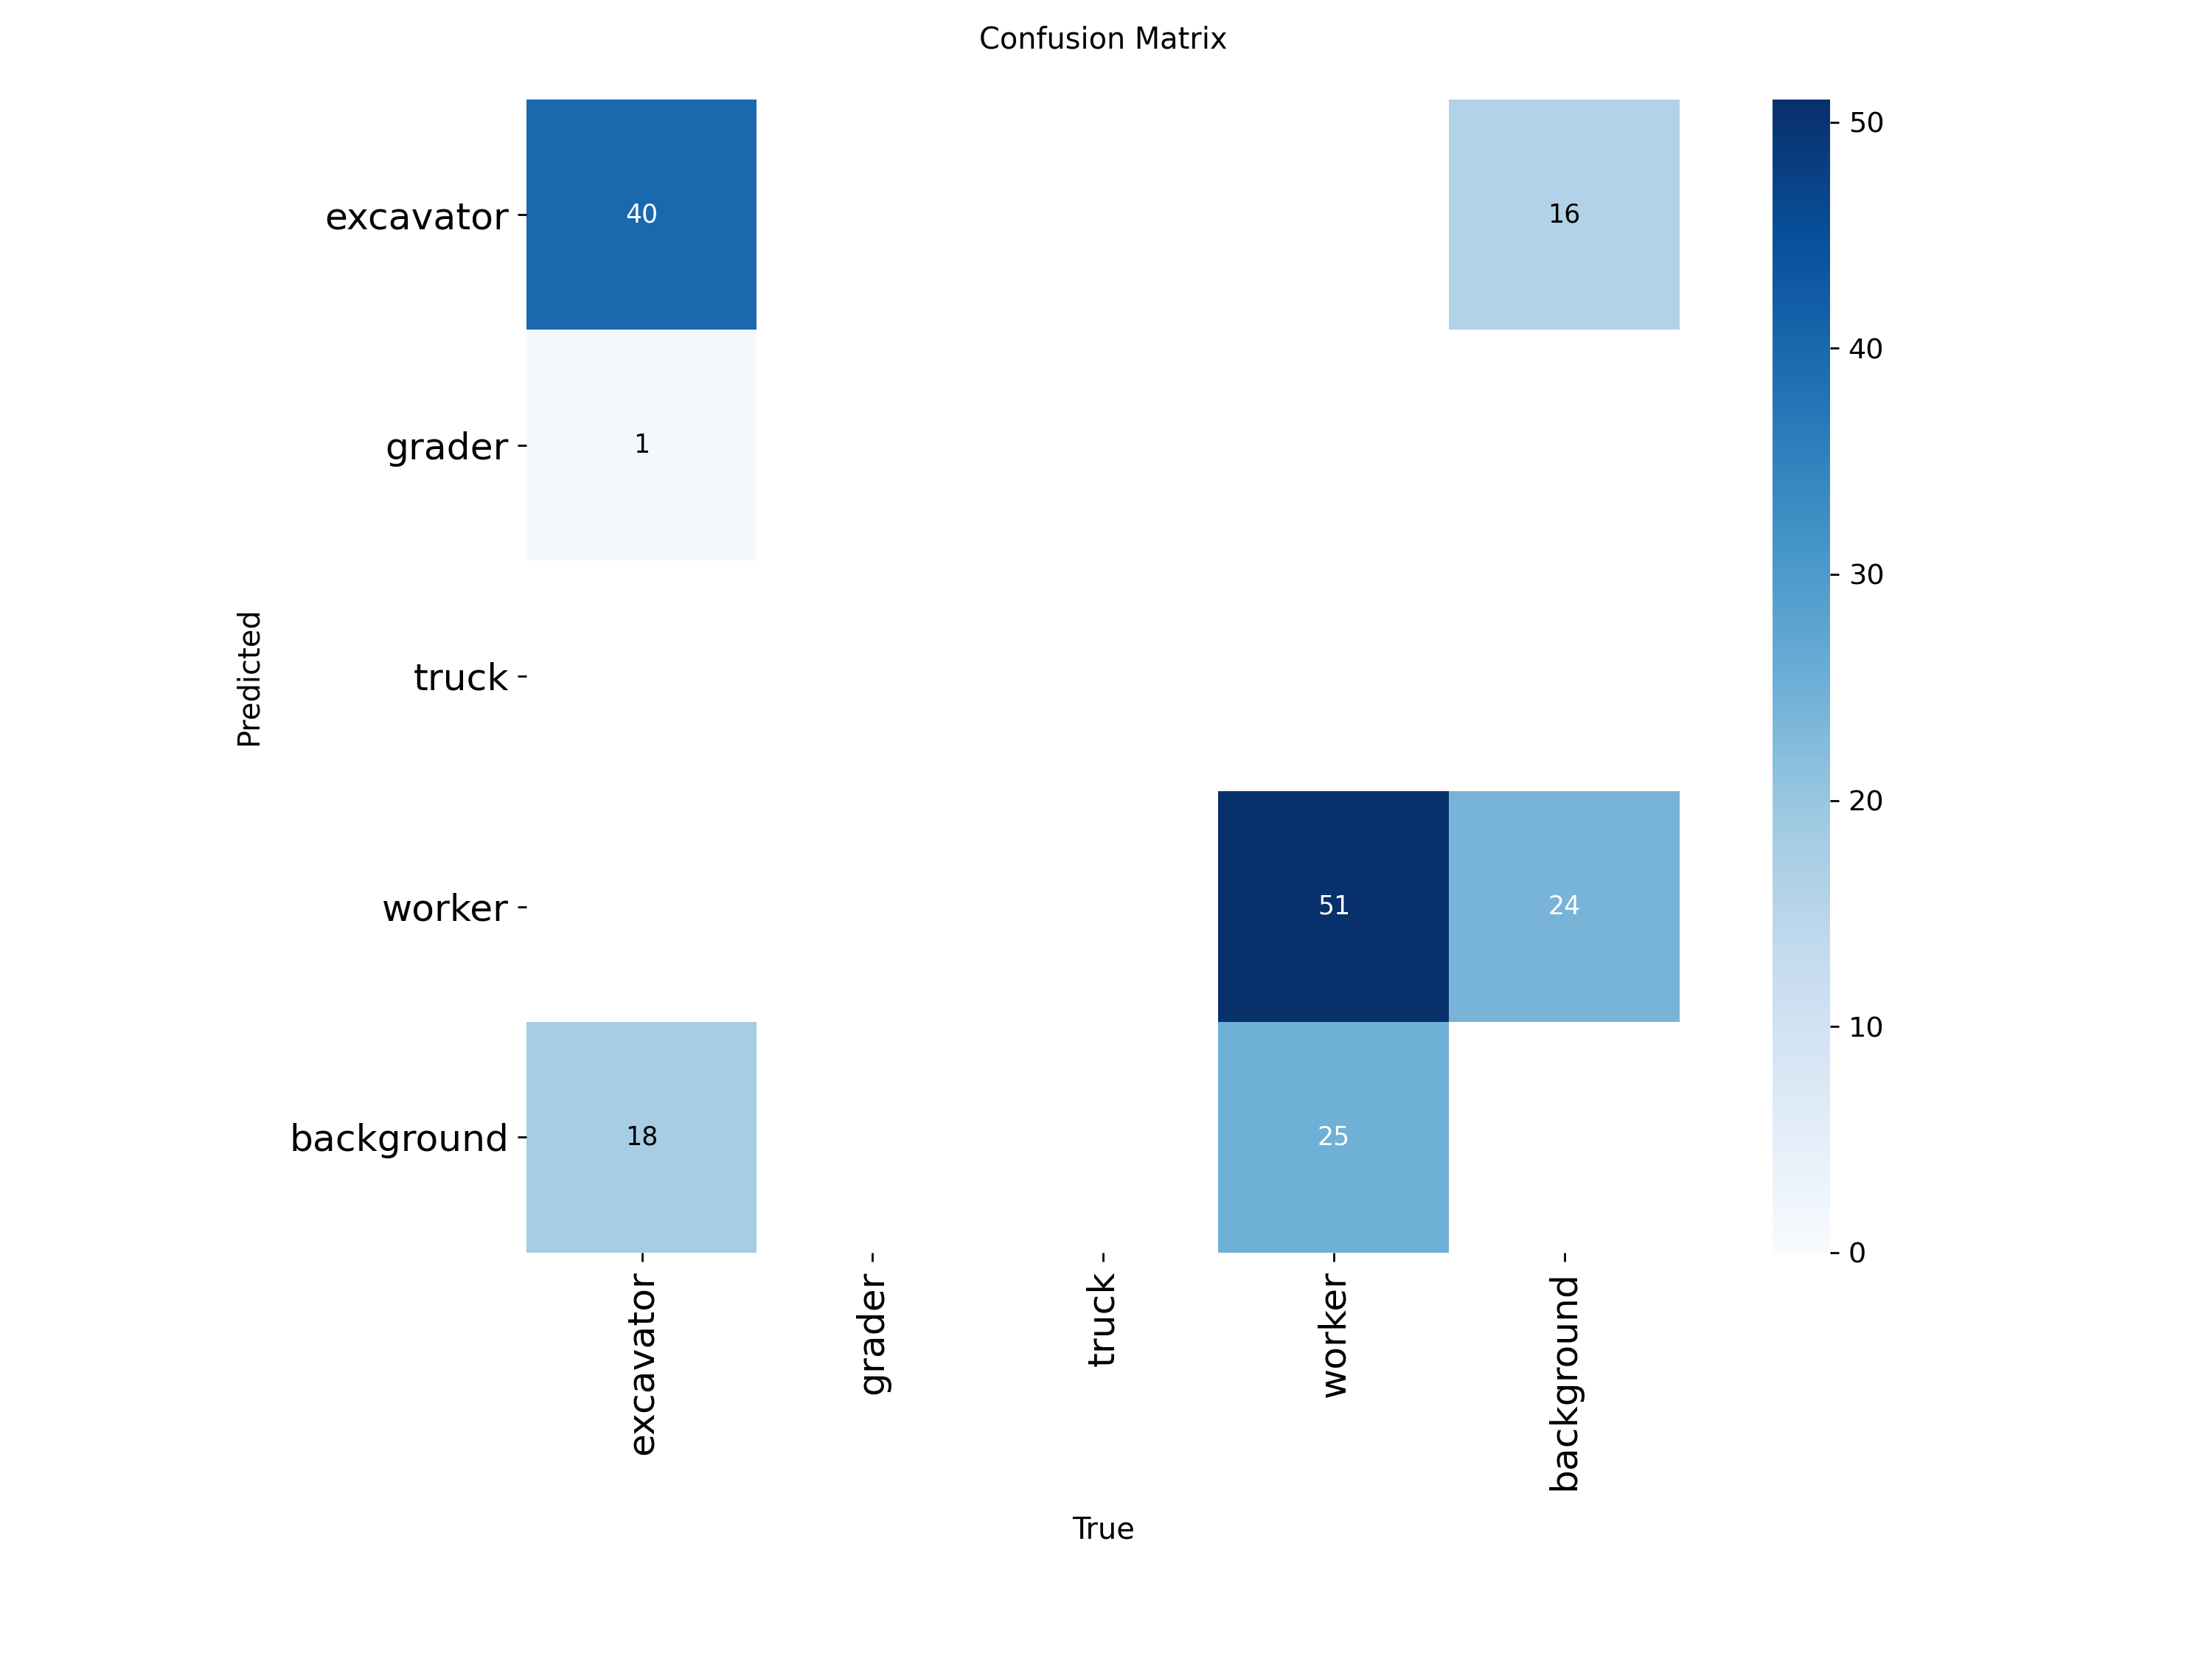


===== confusion_matrix_normalized.png =====


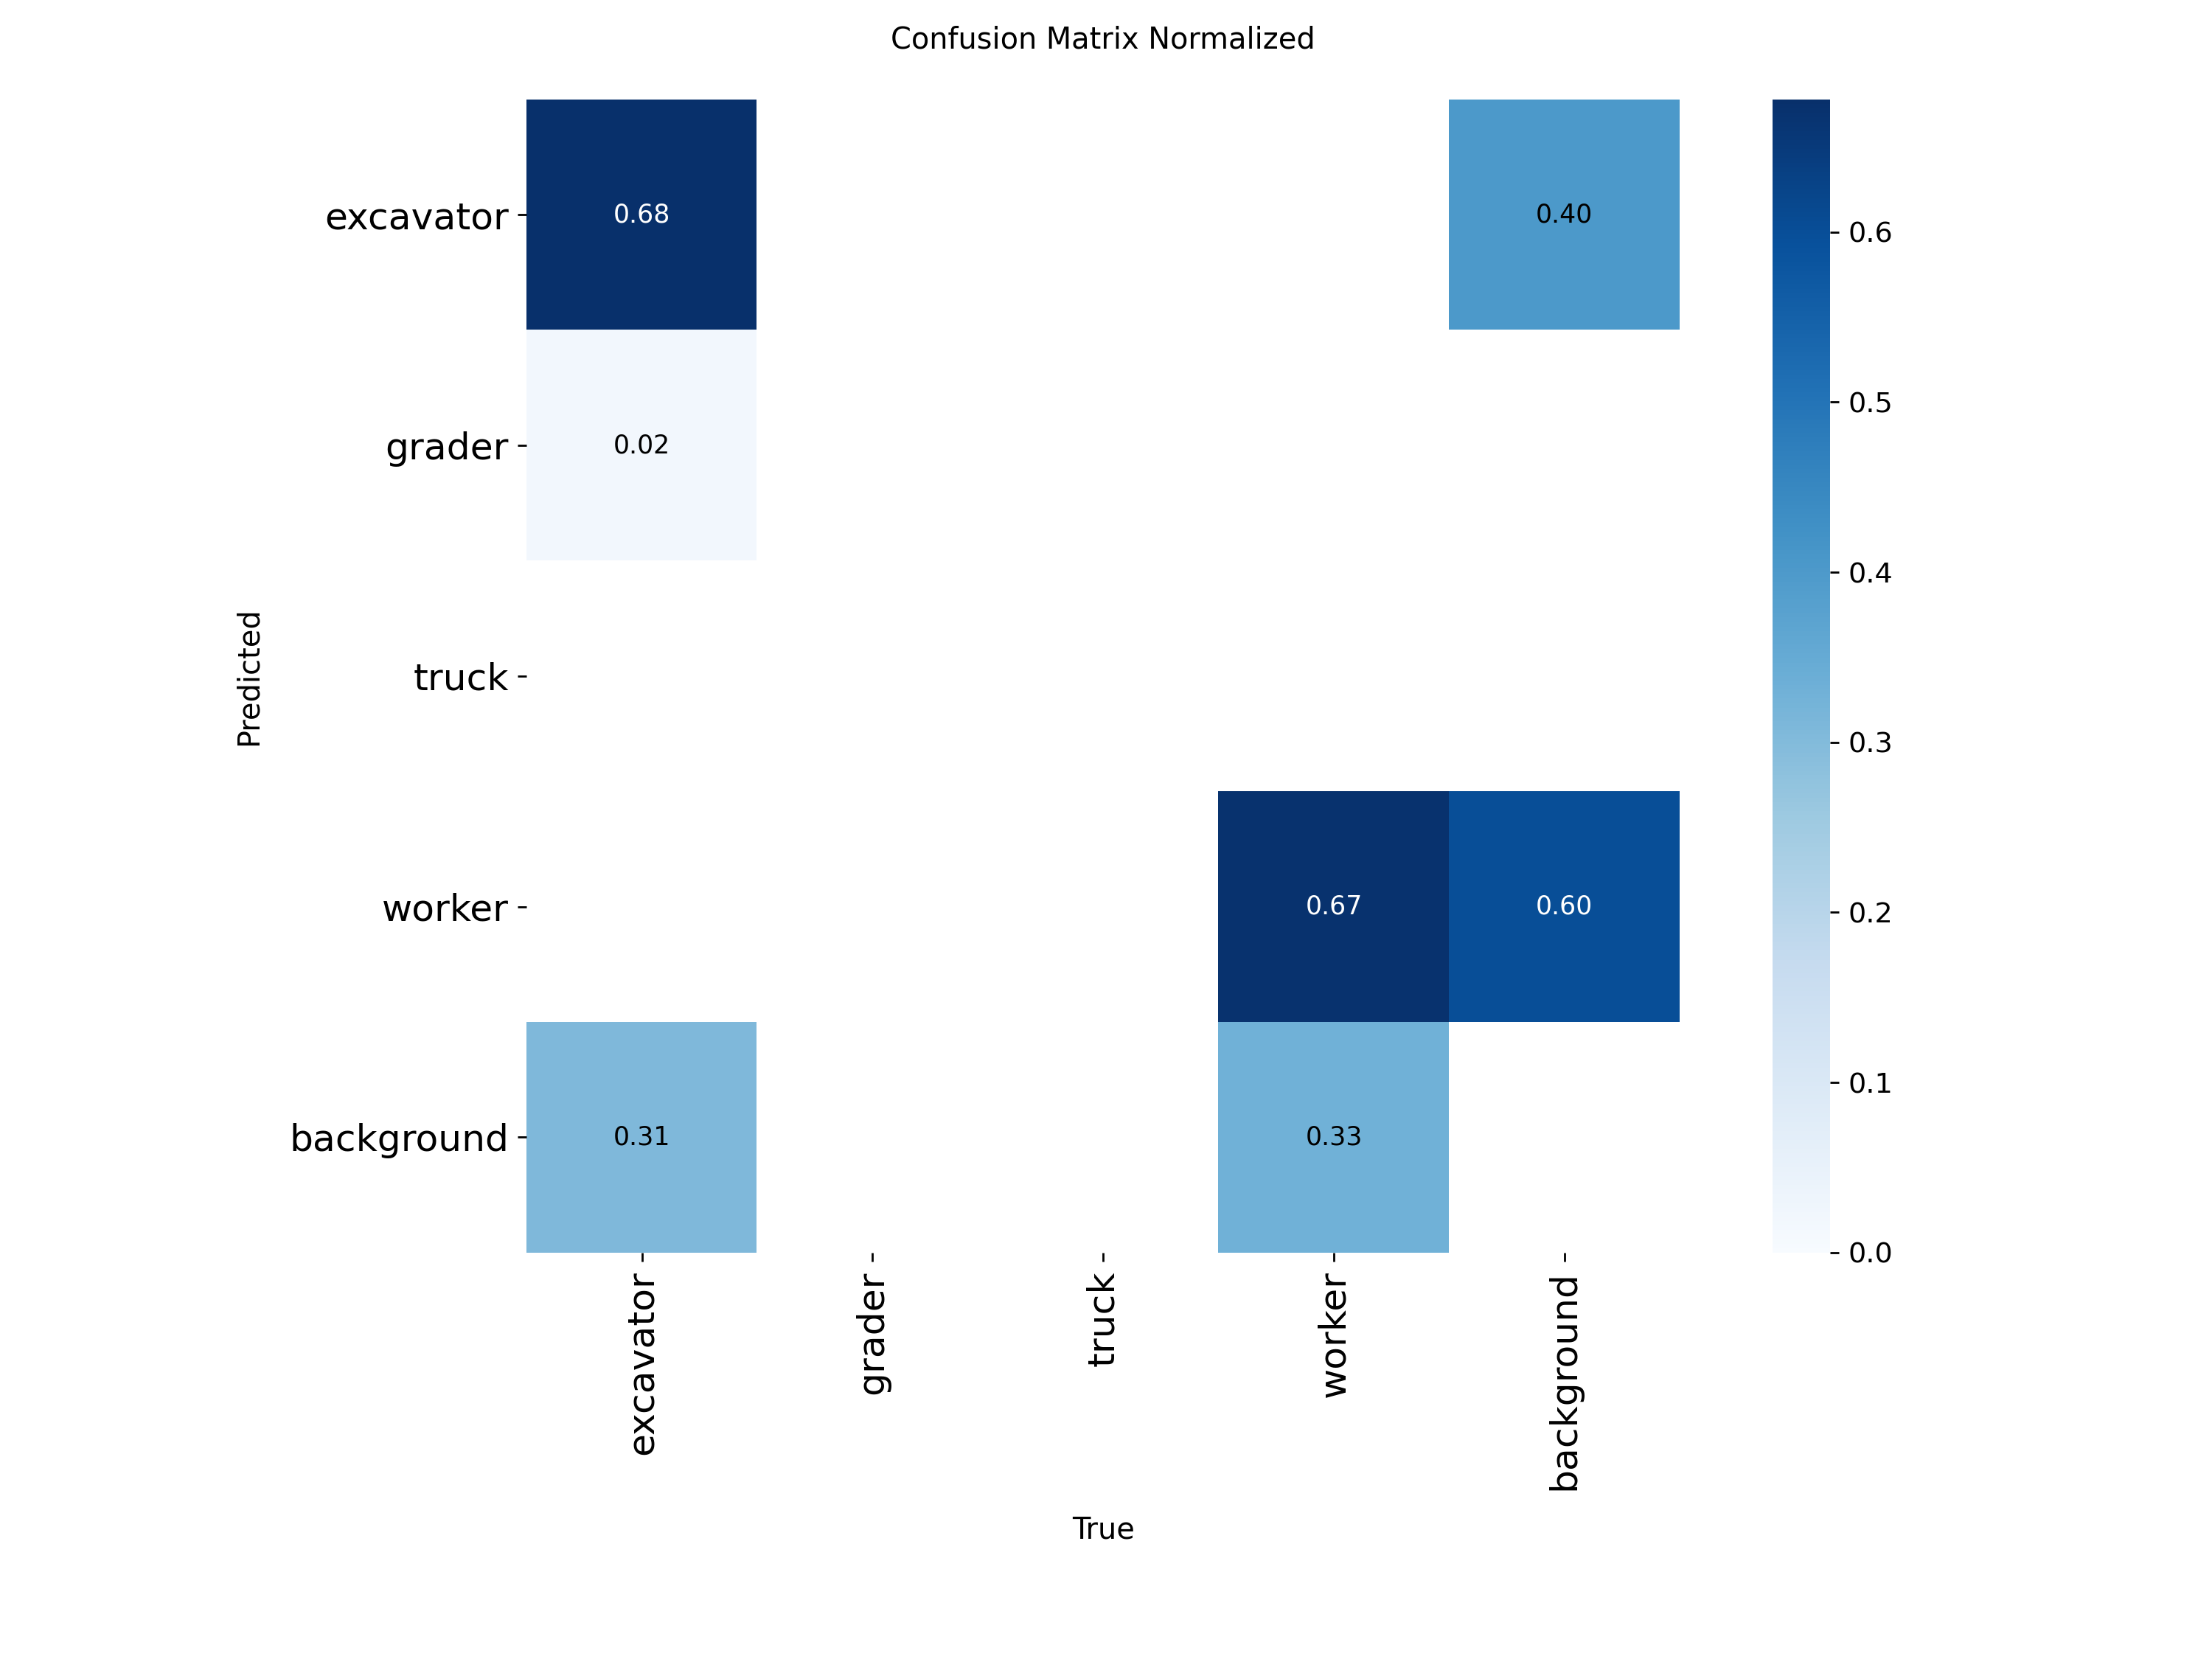


===== BoxPR_curve.png =====


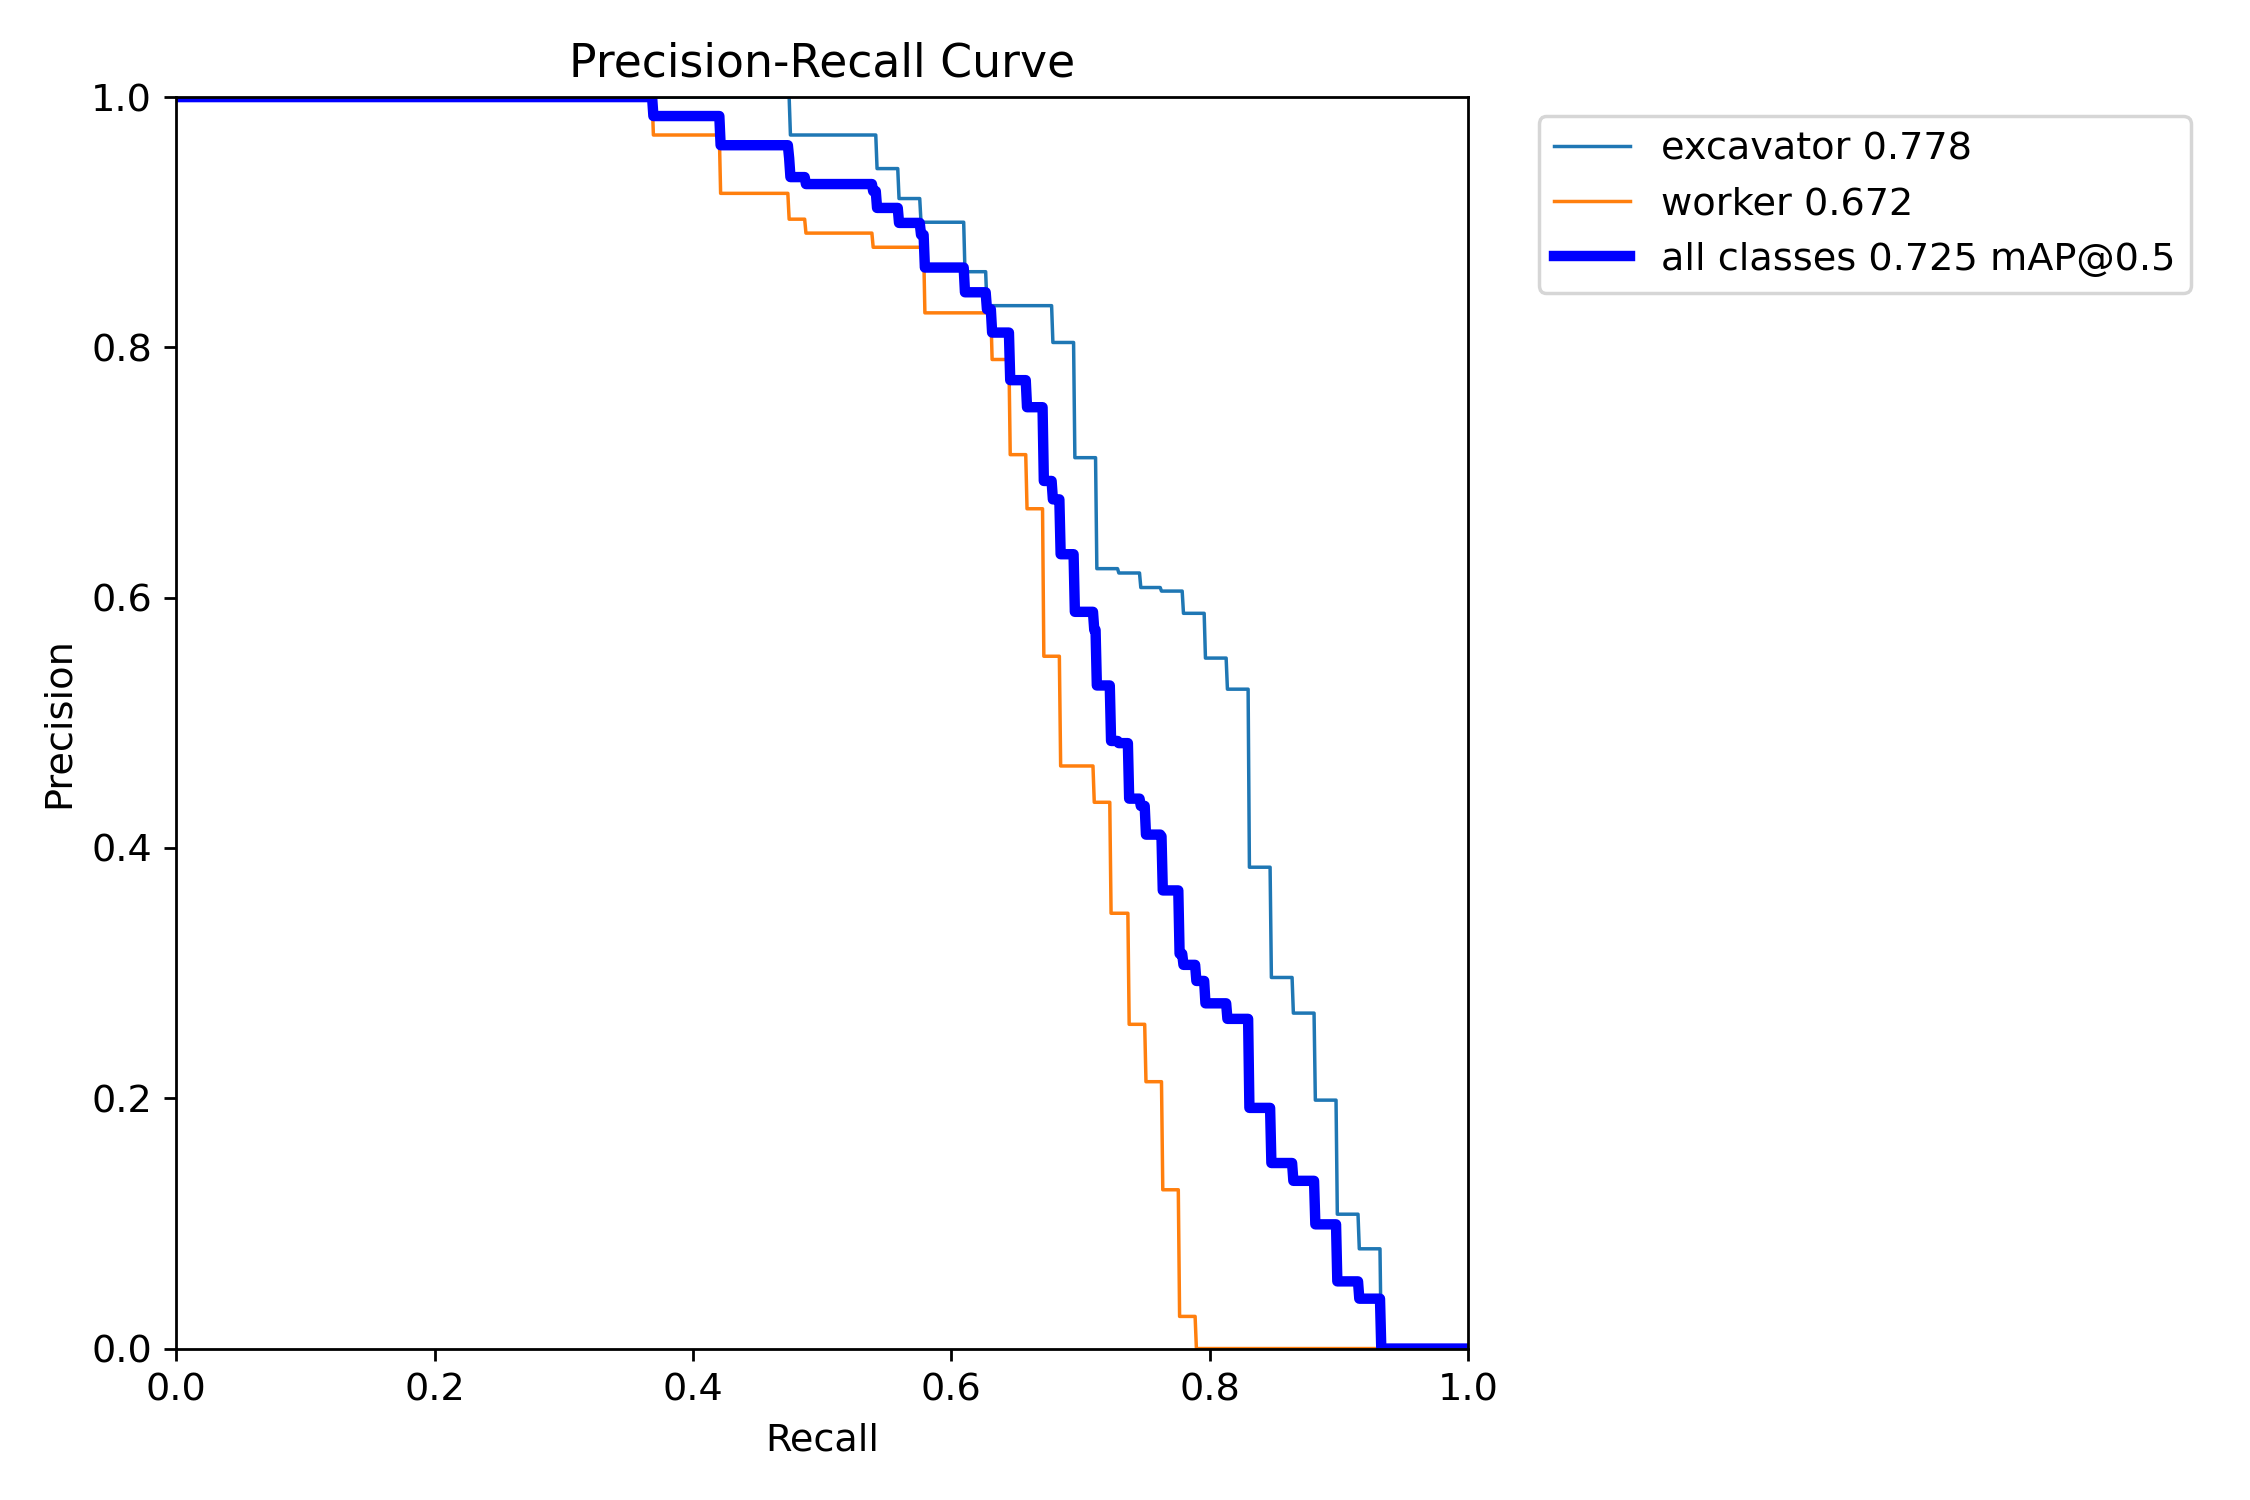


===== BoxF1_curve.png =====


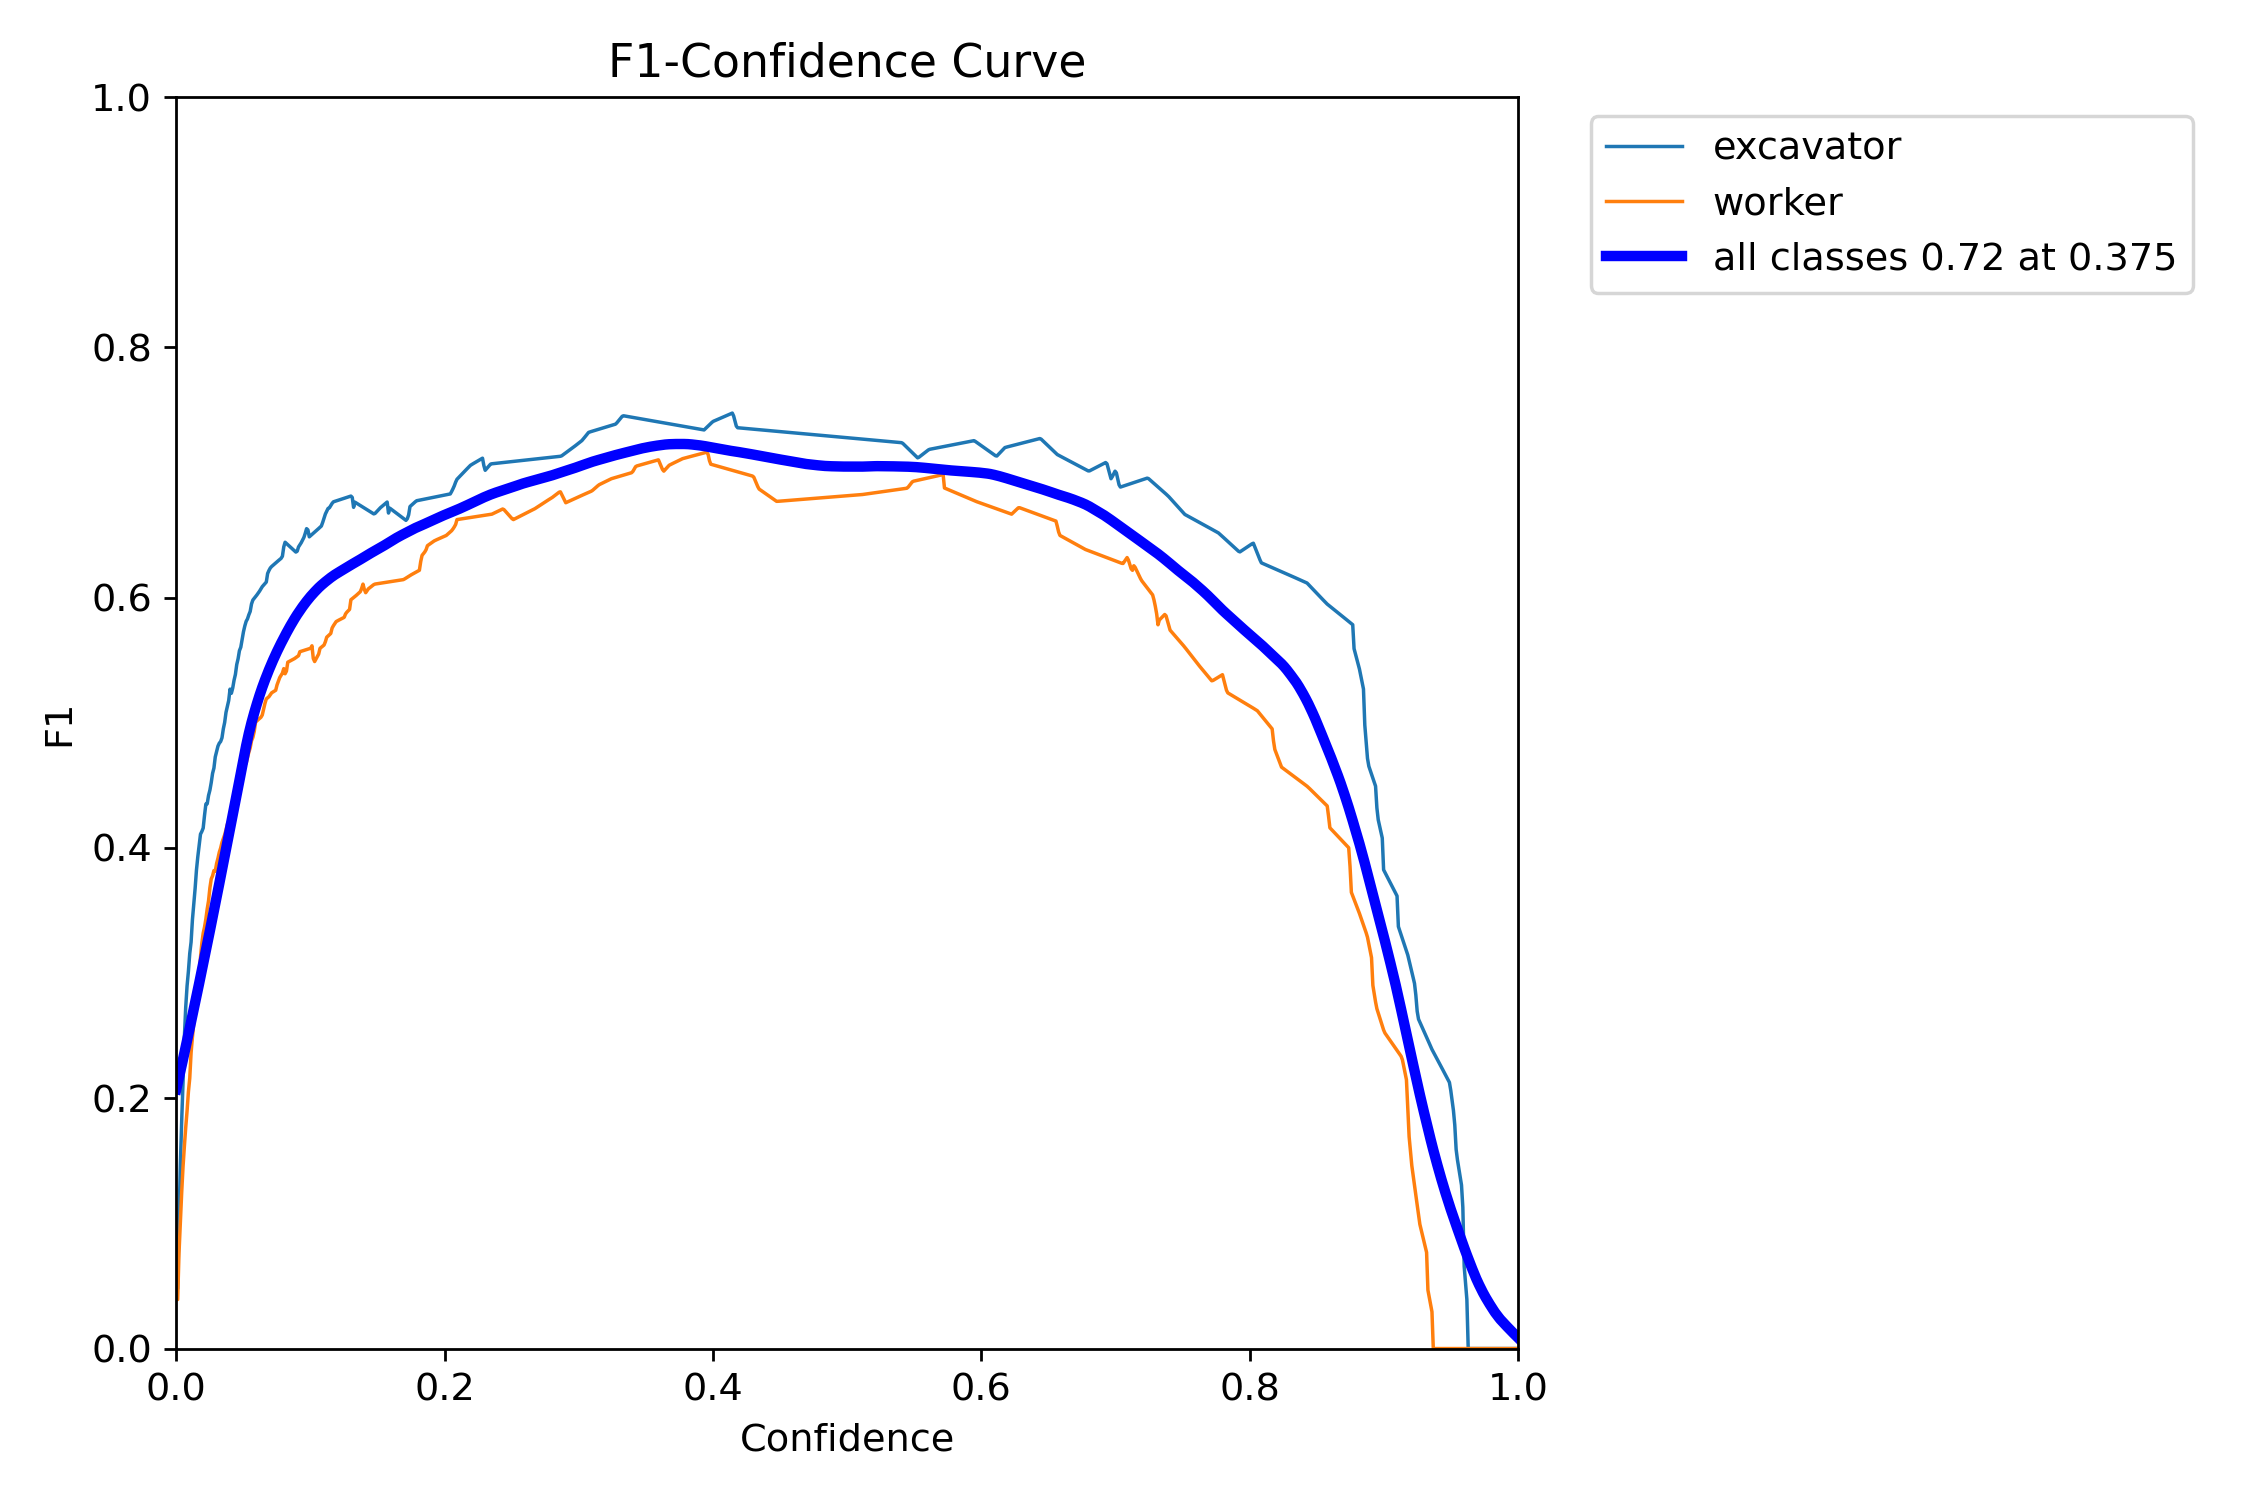

In [13]:
# Cell 13 - Display evaluation plots

from IPython.display import Image, display
import os

RUN_DIR = "/content/runs/construction_yolov8n"

plots = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png"
]

for plot in plots:
    path = os.path.join(RUN_DIR, plot)

    if os.path.exists(path):
        print(f"\n===== {plot} =====")
        display(Image(filename=path, width=850))
    else:
        print(f"{plot} not found.")

In [14]:
# Cell 14 - Create folder for completely unseen test images

import os

NEW_IMAGES_DIR = "/content/new_images"
os.makedirs(NEW_IMAGES_DIR, exist_ok=True)

print("Folder created:", NEW_IMAGES_DIR)
print("Upload new construction-site images into this folder.")

Folder created: /content/new_images
Upload new construction-site images into this folder.


In [15]:
# Restore required package after Colab runtime restart
!pip install -q ultralytics

from ultralytics import YOLO
print("Ultralytics installed successfully.")

Ultralytics installed successfully.


In [16]:
import os

BEST_MODEL = "/content/runs/construction_yolov8n/weights/best.pt"
NEW_IMAGES_DIR = "/content/new_images"

print("Best model exists:", os.path.exists(BEST_MODEL))
print("New images folder exists:", os.path.exists(NEW_IMAGES_DIR))

if os.path.exists(NEW_IMAGES_DIR):
    print("Number of files in new_images:", len(os.listdir(NEW_IMAGES_DIR)))

Best model exists: True
New images folder exists: True
Number of files in new_images: 0


In [17]:
import os
import glob

print("Searching for trained YOLO weights...")

weights = glob.glob("/content/*/.pt", recursive=True)

if weights:
    print(f"Found {len(weights)} .pt file(s):")
    for w in weights:
        print(w)
else:
    print("No .pt files found in /content")

Searching for trained YOLO weights...
No .pt files found in /content


In [18]:
import os

DATASET_DIR = "/content/dataset"
YAML_PATH = "/content/dataset/data.yaml"

print("Dataset folder exists:", os.path.exists(DATASET_DIR))
print("data.yaml exists:", os.path.exists(YAML_PATH))

if os.path.exists(DATASET_DIR):
    print("Dataset contents:")
    print(os.listdir(DATASET_DIR))

Dataset folder exists: True
data.yaml exists: True
Dataset contents:
['README.roboflow.txt', 'valid', 'README.dataset.txt', 'train', 'data.yaml']


In [19]:
# Re-download frozen YOLOv8 dataset from GitHub Release

import os
import zipfile

DATASET_URL = "https://github.com/MohamedElsayed356/construction-site-object-detection-yolov8/releases/download/dataset-v1.0/Construction.Site.Object.Detecti.v1i.yolov8.zip"

ZIP_PATH = "/content/dataset.zip"
DATASET_DIR = "/content/dataset"

# Download
!wget -q --show-progress "$DATASET_URL" -O "$ZIP_PATH"

# Create clean dataset directory
os.makedirs(DATASET_DIR, exist_ok=True)

# Extract
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATASET_DIR)

print("\nDataset downloaded and extracted successfully.")
print("Dataset contents:", os.listdir(DATASET_DIR))
print("data.yaml exists:", os.path.exists("/content/dataset/data.yaml"))

/content/dataset.zi 100%[===================>]  25.57M  --.-KB/s    in 0.05s   

Dataset downloaded and extracted successfully.
Dataset contents: ['README.roboflow.txt', 'valid', 'README.dataset.txt', 'train', 'data.yaml']
data.yaml exists: True


In [20]:
# Fix data.yaml paths for Google Colab

import yaml

YAML_PATH = "/content/dataset/data.yaml"

with open(YAML_PATH, "r") as f:
    data = yaml.safe_load(f)

# Set absolute Colab paths
data["train"] = "/content/dataset/train/images"
data["val"] = "/content/dataset/valid/images"

# This frozen dataset has no test split
data.pop("test", None)

with open(YAML_PATH, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("Updated data.yaml:\n")

with open(YAML_PATH, "r") as f:
    print(f.read())

Updated data.yaml:

train: /content/dataset/train/images
val: /content/dataset/valid/images
nc: 4
names:
- excavator
- grader
- truck
- worker
roboflow:
  workspace: keshta_mido2000-yahoo-com
  project: construction-site-object-detecti-l8wfp
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/keshta_mido2000-yahoo-com/construction-site-object-detecti-l8wfp/dataset/1



In [21]:
# Train YOLOv8n for 50 epochs

from ultralytics import YOLO

# Load pretrained YOLOv8 nano model
model = YOLO("yolov8n.pt")

# Train
results = model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/runs",
    name="construction_yolov8n",
    exist_ok=True,
    seed=42
)

print("\nTraining completed successfully.")
print("Best model:")
print("/content/runs/construction_yolov8n/weights/best.pt")

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=construction_yolov8n, nbs=64, nms=None, opset=None

In [22]:
# Backup trained model before continuing

from google.colab import files
import os

BEST_MODEL = "/content/runs/construction_yolov8n/weights/best.pt"

print("Best model exists:", os.path.exists(BEST_MODEL))
print("Model size:", round(os.path.getsize(BEST_MODEL) / (1024**2), 2), "MB")

files.download(BEST_MODEL)

Best model exists: True
Model size: 5.96 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

New unseen images found: 25

image 1/25 /content/new_images/WhatsApp Image 2026-09-26 at 14.12.00.jpeg: 384x640 3 workers, 5.8ms
image 2/25 /content/new_images/WhatsApp Image 2026-09-26 at 14.12.01.jpeg: 384x640 1 worker, 7.8ms
image 3/25 /content/new_images/WhatsApp Image 2026-09-26 at 14.12.06.jpeg: 384x640 (no detections), 9.0ms
image 4/25 /content/new_images/WhatsApp Image 2026-09-26 at 14.12.09 (1).jpeg: 640x384 1 worker, 51.1ms
image 5/25 /content/new_images/WhatsApp Image 2026-09-26 at 14.12.09.jpeg: 384x640 (no detections), 10.8ms
image 6/25 /content/new_images/WhatsApp Image 2026-09-26 at 14.12.10.jpeg: 480x640 3 excavators, 2 workers, 43.4ms
image 7/25 /content/new_images/WhatsApp Image 2026-09-26 at 14.13.04 (1).jpeg: 640x384 2 workers, 12.0ms
image 8/25 /content/new_images/WhatsApp Image 2026-09-26 at 14.13.04 (2).jpeg: 384x640 (no detections), 9.3ms
image 9/25 /content/new_images/WhatsApp Image 2026-09-26 at 14.13.04.jpeg: 640x384 2 excavators, 1 worker, 8.9ms
image 10/25 

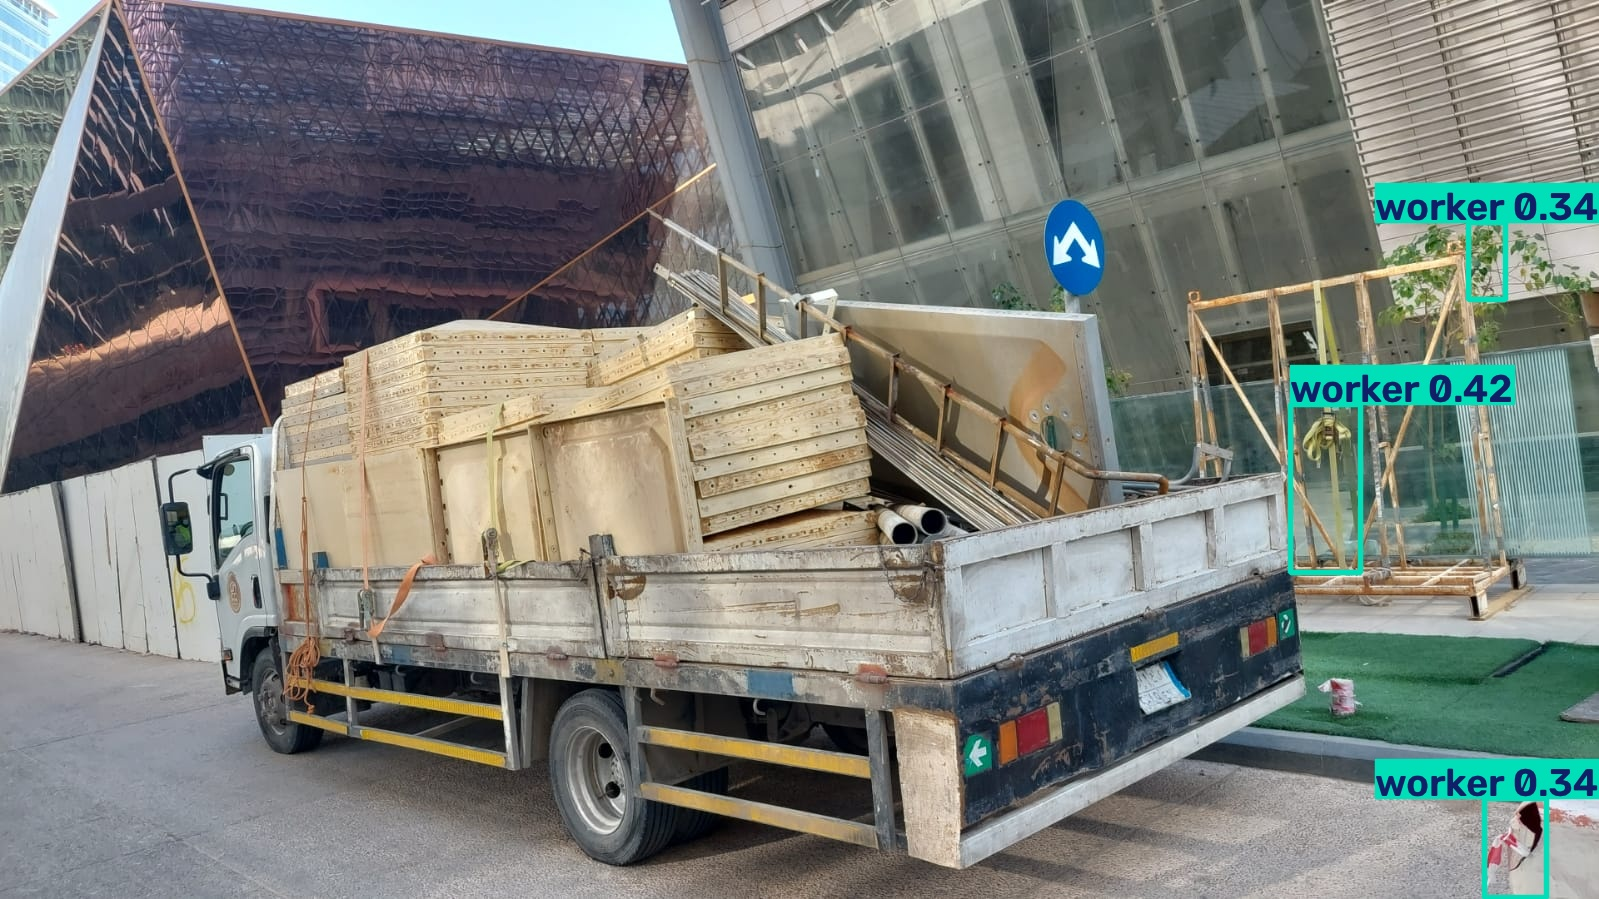


===== Unseen Image 2 =====
WhatsApp Image 2026-09-26 at 14.12.01.jpg


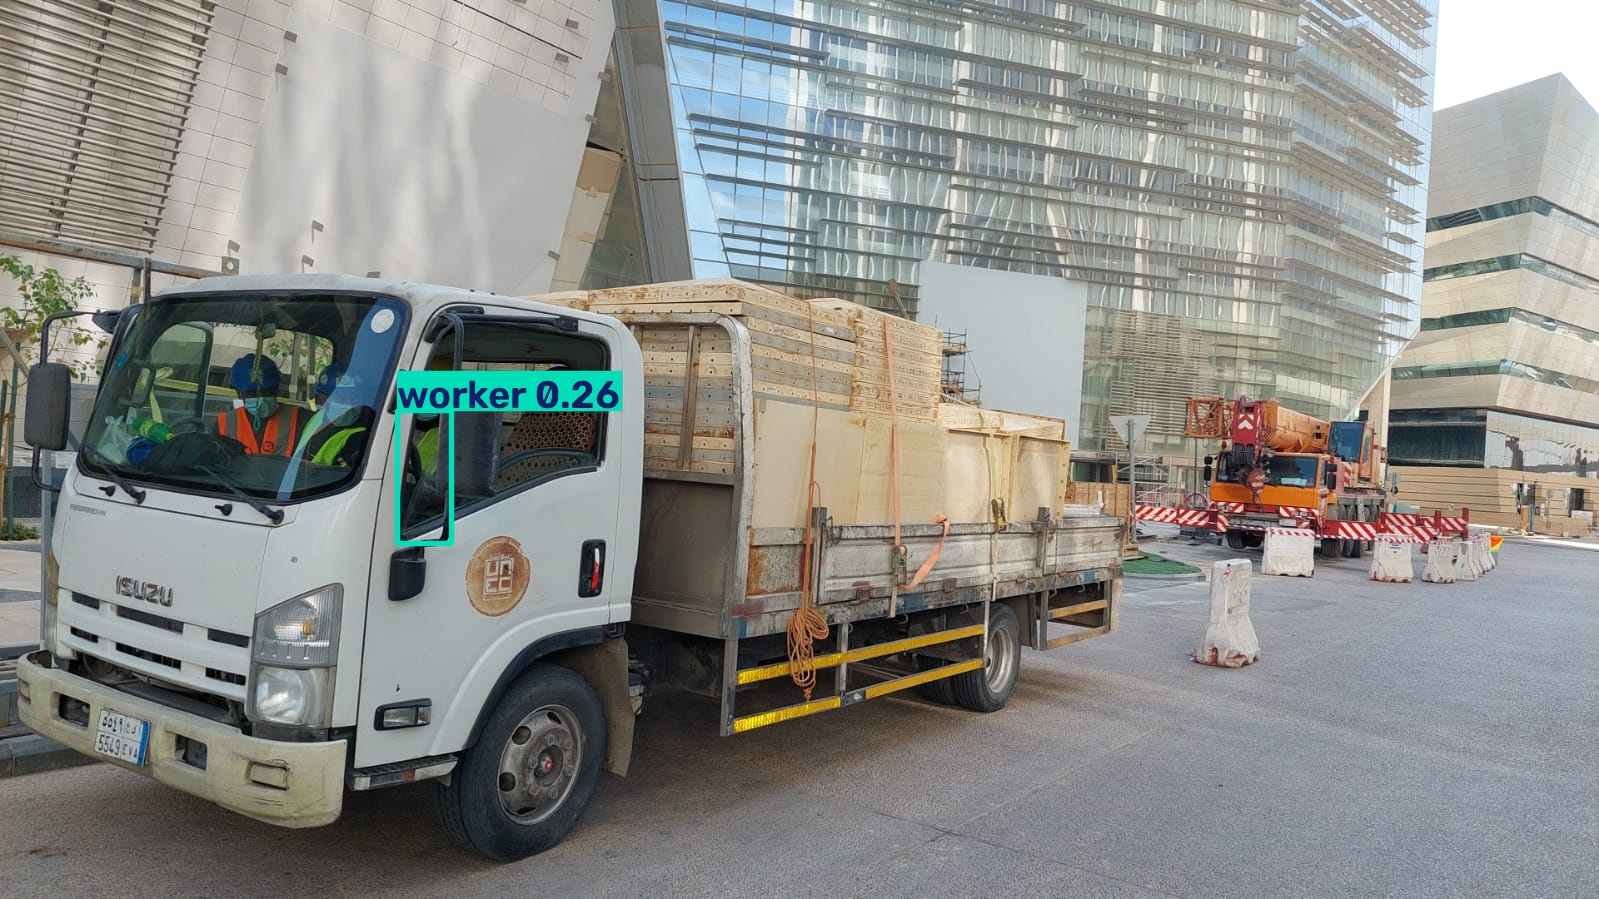


===== Unseen Image 3 =====
WhatsApp Image 2026-09-26 at 14.12.06.jpg


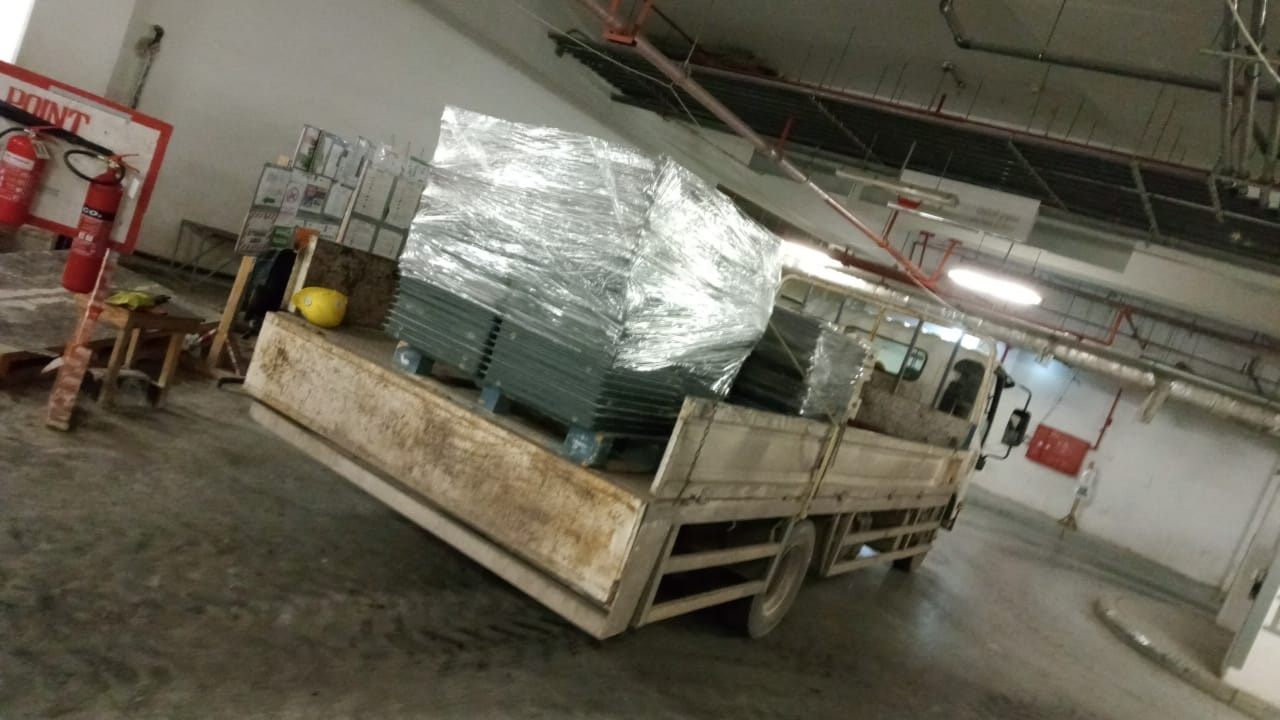


===== Unseen Image 4 =====
WhatsApp Image 2026-09-26 at 14.12.09 (1).jpg


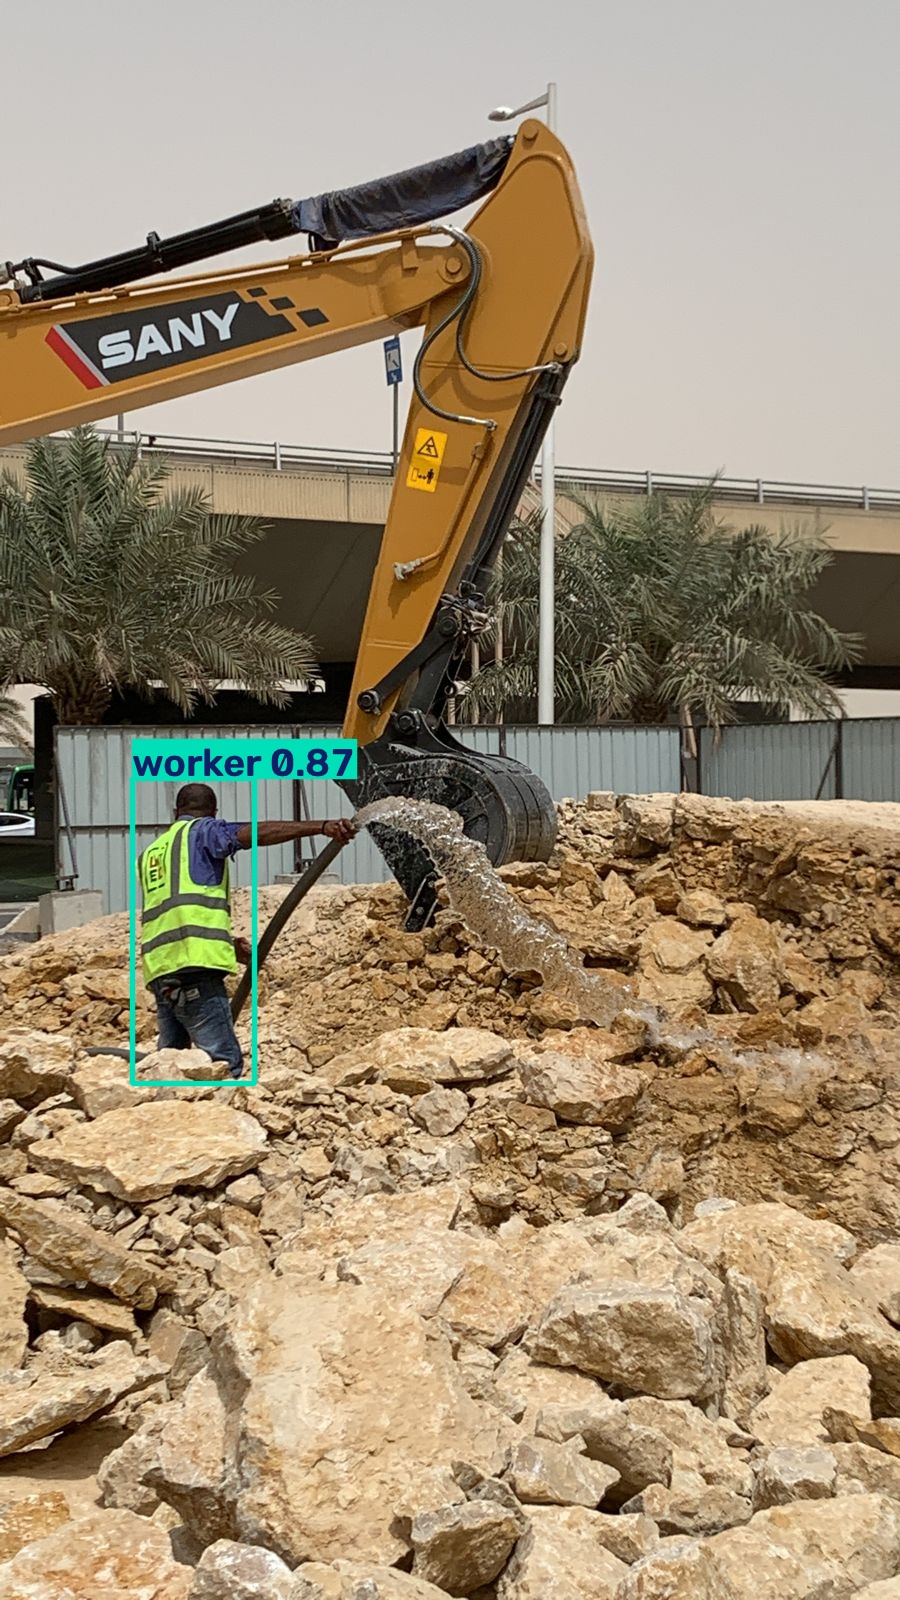


===== Unseen Image 5 =====
WhatsApp Image 2026-09-26 at 14.12.09.jpg


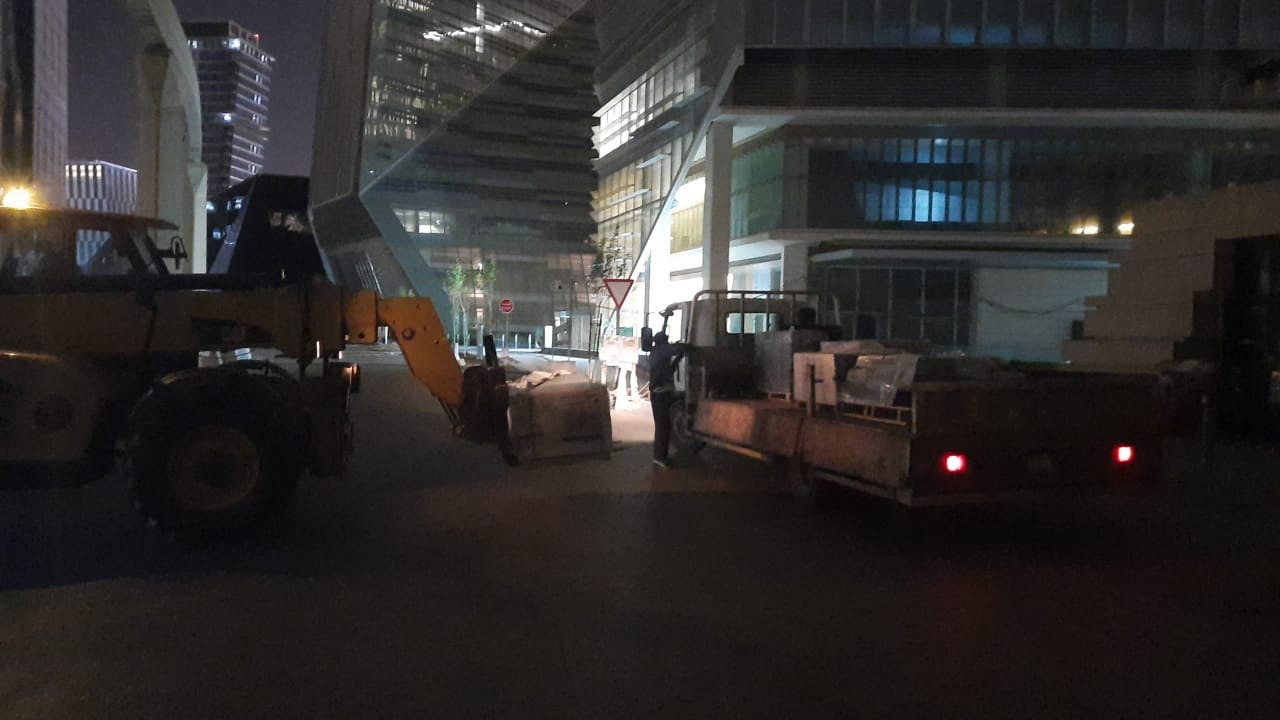


===== Unseen Image 6 =====
WhatsApp Image 2026-09-26 at 14.12.10.jpg


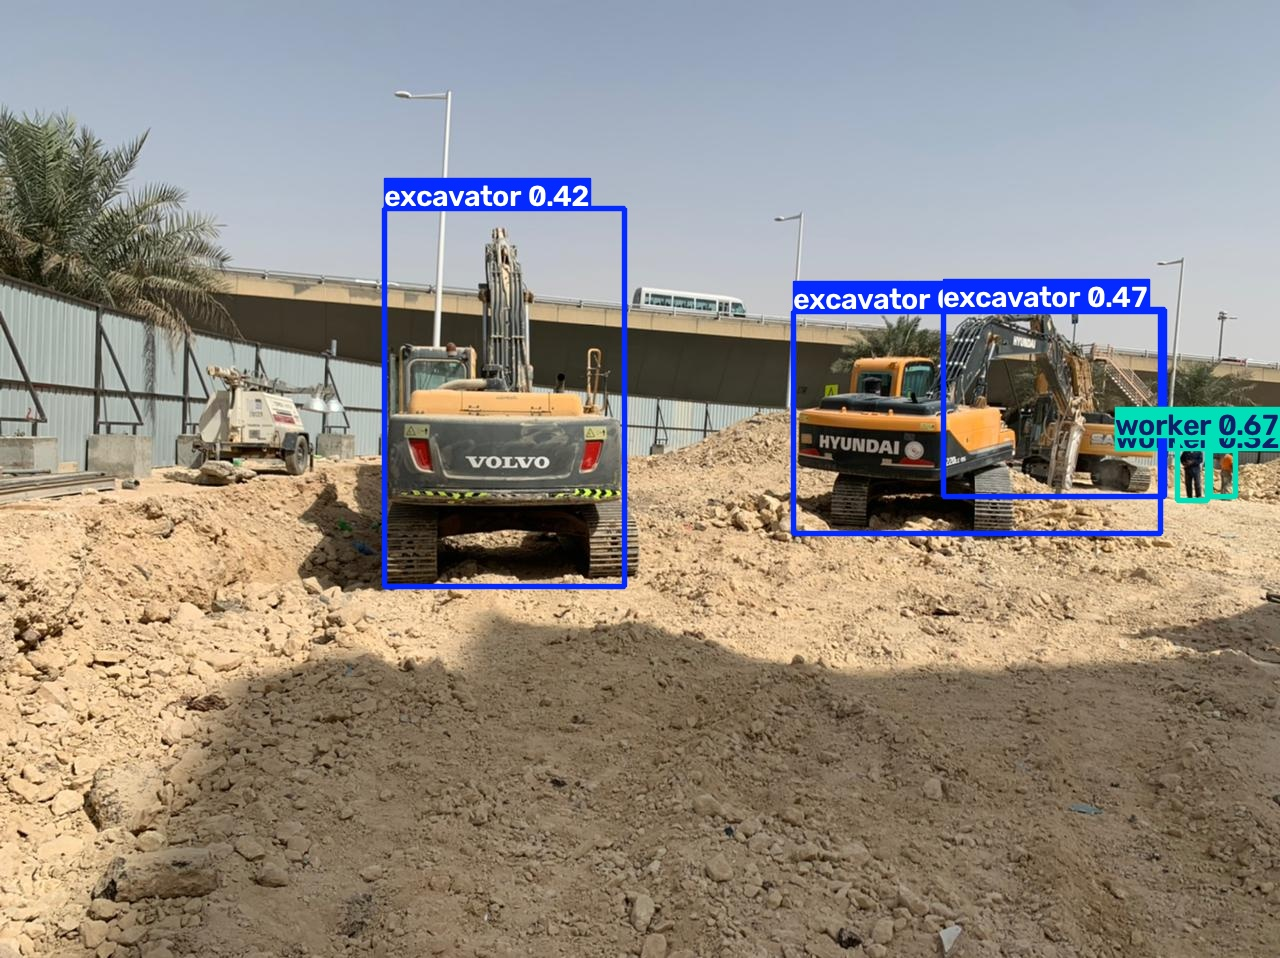


===== Unseen Image 7 =====
WhatsApp Image 2026-09-26 at 14.13.04 (1).jpg


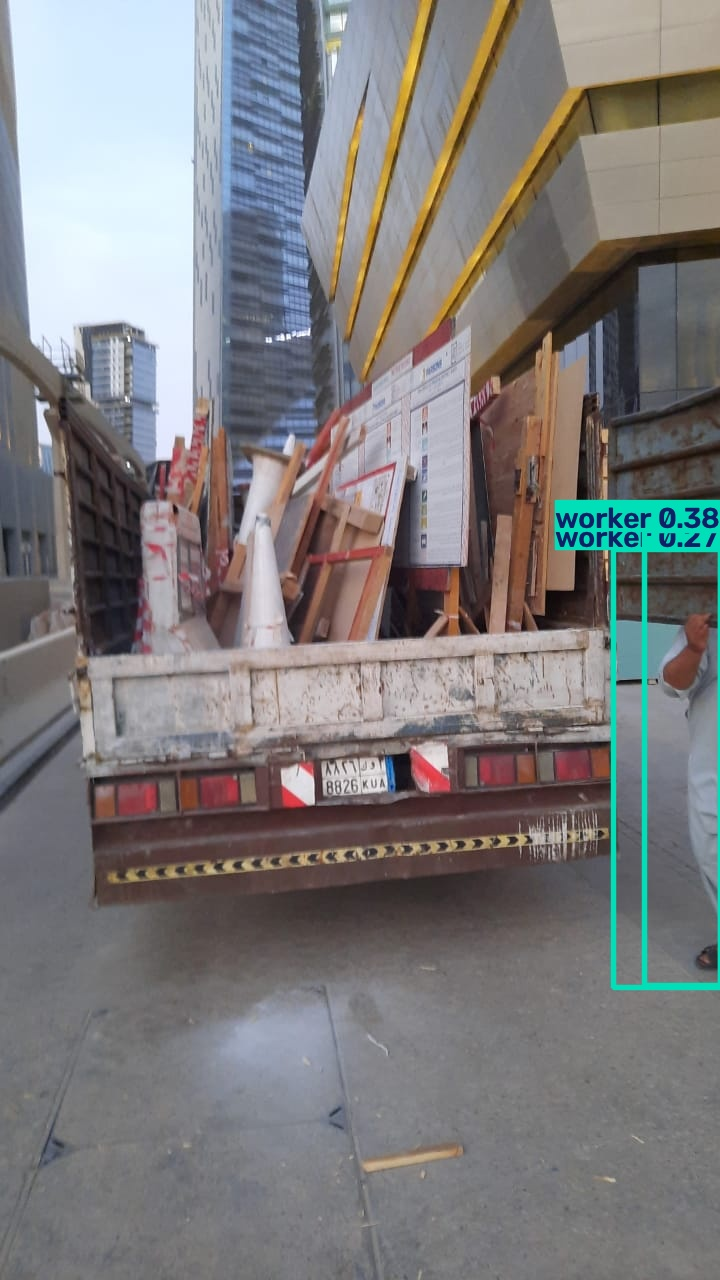


===== Unseen Image 8 =====
WhatsApp Image 2026-09-26 at 14.13.04 (2).jpg


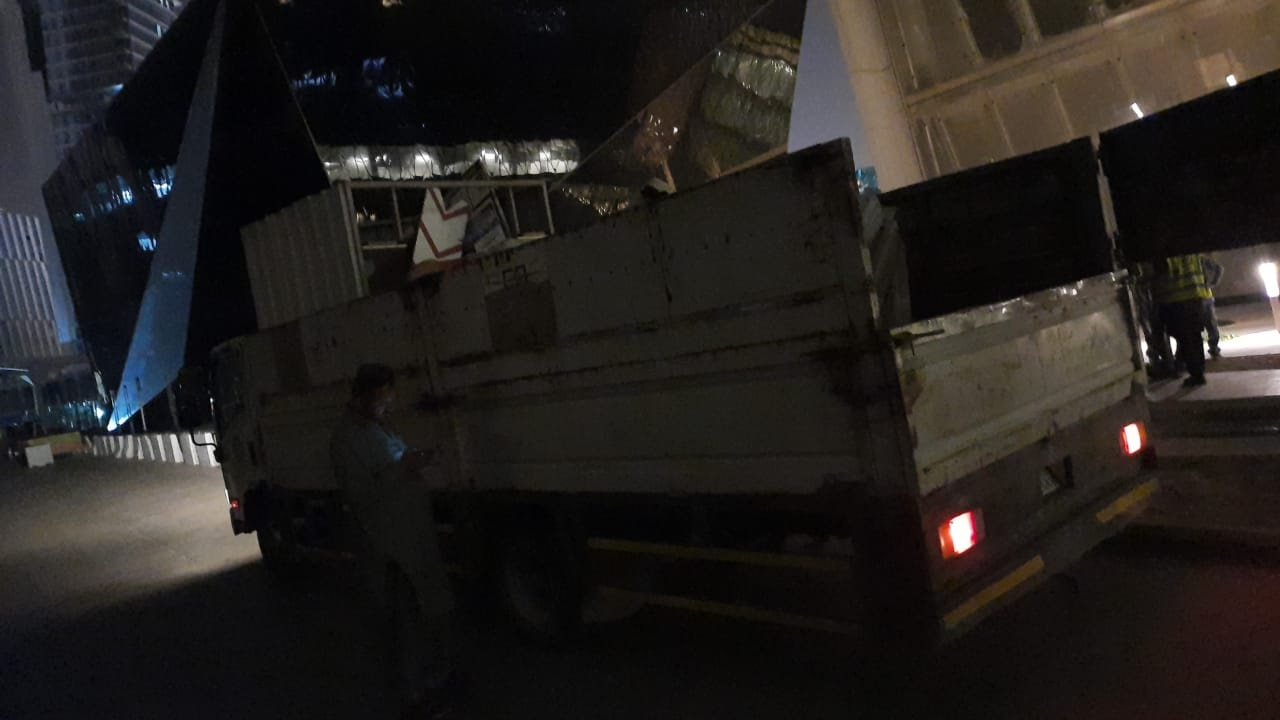


===== Unseen Image 9 =====
WhatsApp Image 2026-09-26 at 14.13.04.jpg


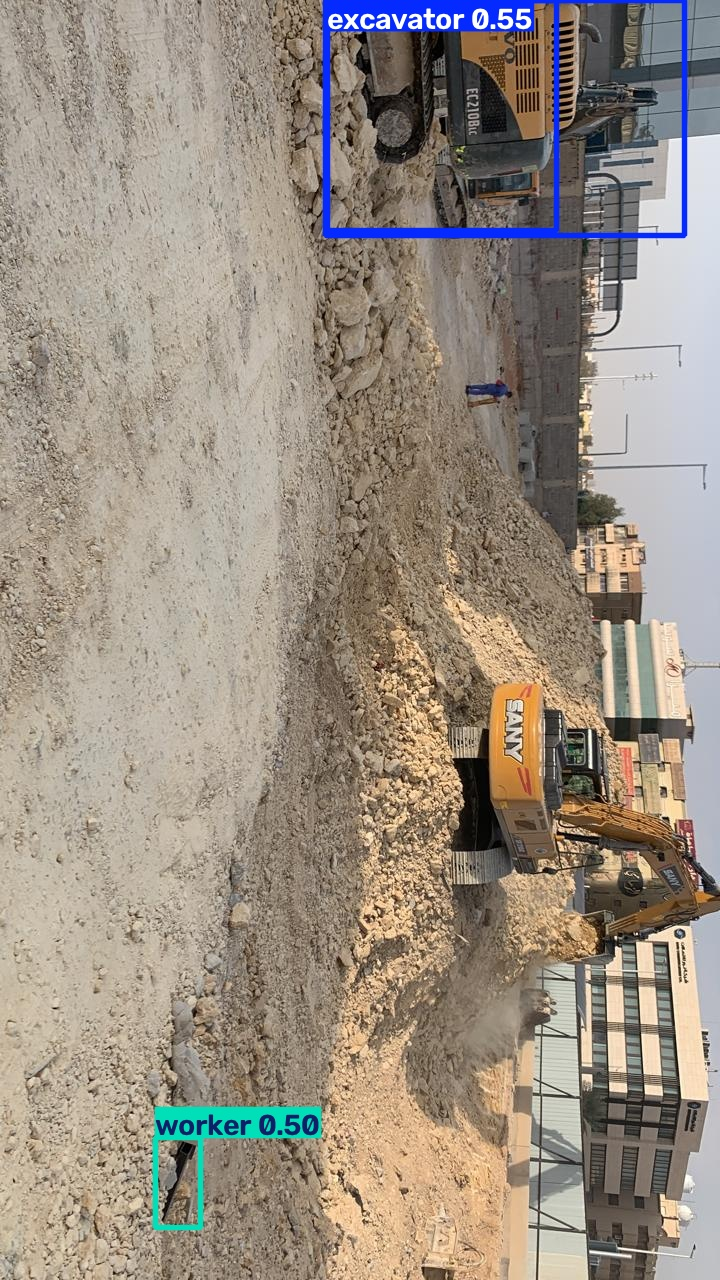


===== Unseen Image 10 =====
WhatsApp Image 2026-09-26 at 14.13.05 (1).jpg


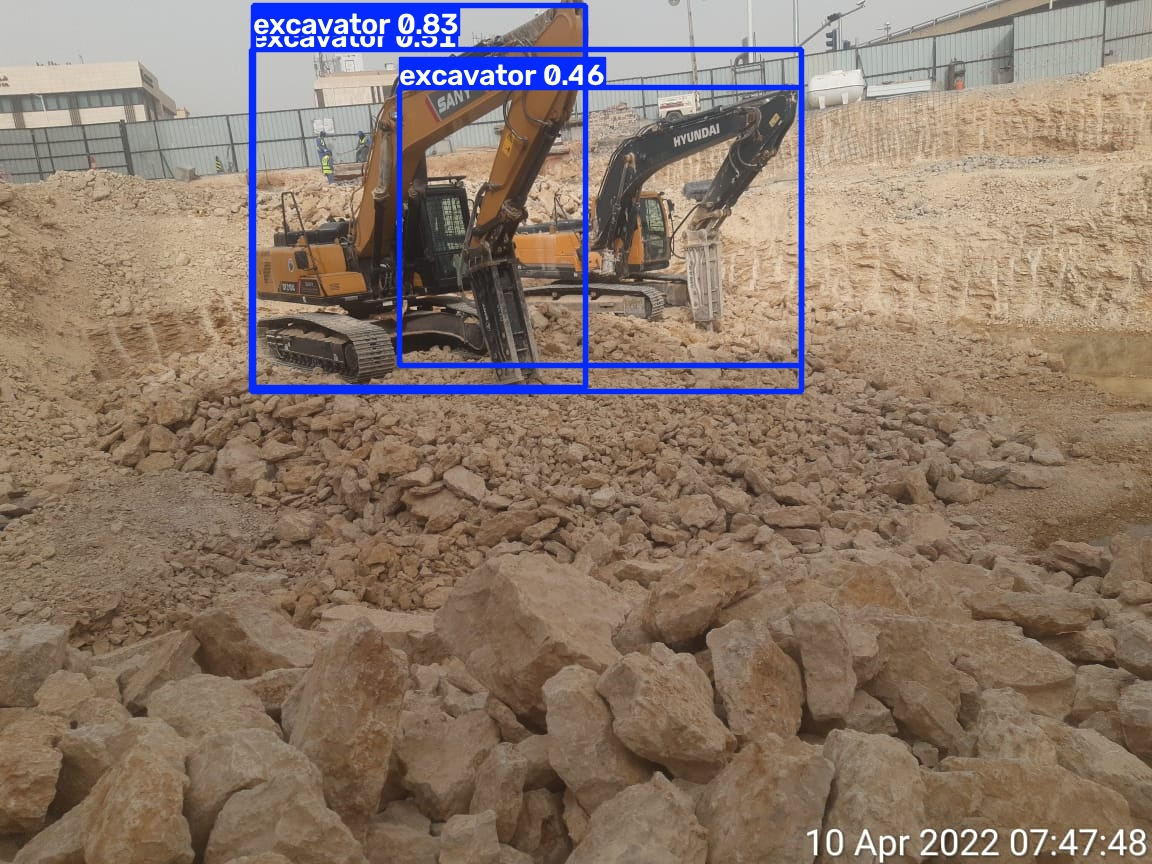

In [24]:
# Cell 15 - Run inference on completely unseen construction-site images

# Cell 15 - Run inference on completely unseen construction-site images

from ultralytics import YOLO
from IPython.display import Image, display
import glob
import os
import shutil
import subprocess

BEST_MODEL = "/content/runs/construction_yolov8n/weights/best.pt"
NEW_IMAGES_DIR = "/content/new_images"
OUTPUT_DIR = "/content/inference"

# ------------------------------------------------------------
# Download the fixed unseen test images from the GitHub repo
# This makes the notebook reproducible in a fresh Colab session
# ------------------------------------------------------------

REPO_URL = "https://github.com/MohamedElsayed356/construction-site-object-detection-yolov8.git"
REPO_DIR = "/content/m4u3_repo"
SOURCE_TEST_DIR = os.path.join(REPO_DIR, "test_images")

# Remove old temporary folders if they exist
if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

if os.path.exists(NEW_IMAGES_DIR):
    shutil.rmtree(NEW_IMAGES_DIR)

# Clone only the latest repository snapshot
subprocess.run(
    ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
    check=True
)

# Verify that the test_images folder exists
if not os.path.isdir(SOURCE_TEST_DIR):
    raise FileNotFoundError(
        f"GitHub test image folder not found: {SOURCE_TEST_DIR}"
    )

# Copy the fixed unseen images to the expected Colab directory
shutil.copytree(SOURCE_TEST_DIR, NEW_IMAGES_DIR)

# Load best trained model
best_model = YOLO(BEST_MODEL)

# Count new images
new_images = (
    glob.glob(f"{NEW_IMAGES_DIR}/*.jpg") +
    glob.glob(f"{NEW_IMAGES_DIR}/*.jpeg") +
    glob.glob(f"{NEW_IMAGES_DIR}/*.png") +
    glob.glob(f"{NEW_IMAGES_DIR}/*.JPG") +
    glob.glob(f"{NEW_IMAGES_DIR}/*.JPEG") +
    glob.glob(f"{NEW_IMAGES_DIR}/*.PNG")
)

print(f"New unseen images found: {len(new_images)}")

# Run inference
new_results = best_model.predict(
    source=NEW_IMAGES_DIR,
    imgsz=640,
    conf=0.25,
    save=True,
    project=OUTPUT_DIR,
    name="new_images",
    exist_ok=True
)

print(f"\nInference completed on {len(new_results)} unseen images.")
print("Results saved to: /content/inference/new_images")

# Find saved prediction images
prediction_files = sorted(
    glob.glob("/content/inference/new_images/*.jpg") +
    glob.glob("/content/inference/new_images/*.jpeg") +
    glob.glob("/content/inference/new_images/*.png")
)

print(f"Prediction images saved: {len(prediction_files)}")

# Display first 10 prediction images
for i, img_path in enumerate(prediction_files[:10], start=1):
    print(f"\n===== Unseen Image {i} =====")
    print(os.path.basename(img_path))
    display(Image(filename=img_path, width=750))

In [ ]:
# Cell 16 - Quantitative summary of predictions on unseen images

from collections import Counter
import numpy as np

class_counts = Counter()
confidences = []
images_with_detections = 0
images_without_detections = 0

for result in new_results:

    if result.boxes is None or len(result.boxes) == 0:
        images_without_detections += 1
        continue

    images_with_detections += 1

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        class_name = result.names[class_id]

        class_counts[class_name] += 1
        confidences.append(confidence)

print("===== UNSEEN IMAGE INFERENCE SUMMARY =====")
print(f"Total unseen images: {len(new_results)}")
print(f"Images with detections: {images_with_detections}")
print(f"Images without detections: {images_without_detections}")

print("\nDetected objects by class:")
for class_name in ["excavator", "grader", "truck", "worker"]:
    print(f"{class_name}: {class_counts[class_name]}")

print("\nTotal detections:", sum(class_counts.values()))

if confidences:
    print(f"Mean confidence: {np.mean(confidences):.3f}")
    print(f"Median confidence: {np.median(confidences):.3f}")
    print(f"Minimum confidence: {np.min(confidences):.3f}")
    print(f"Maximum confidence: {np.max(confidences):.3f}")

    print("\nConfidence distribution:")
    print(f"0.25–0.49: {sum(0.25 <= x < 0.50 for x in confidences)}")
    print(f"0.50–0.74: {sum(0.50 <= x < 0.75 for x in confidences)}")
    print(f"0.75–1.00: {sum(0.75 <= x <= 1.00 for x in confidences)}")

## Error Analysis on Unseen Construction-Site Images

The trained YOLOv8n model was evaluated qualitatively on 25 completely unseen construction-site images that were not included in the training or validation datasets.

### Quantitative Prediction Summary

- Total unseen images: *25*
- Images with at least one detection: *19*
- Images without detections: *6*
- Total predicted objects: *50*
- Excavator detections: *25*
- Grader detections: *6*
- Truck detections: *1*
- Worker detections: *18*
- Mean prediction confidence: *0.601*
- Median prediction confidence: *0.545*
- Confidence range: *0.253–0.982*

Confidence distribution:

- 0.25–0.49: *21 detections*
- 0.50–0.74: *11 detections*
- 0.75–1.00: *18 detections*

### Observed Strengths

The model successfully generalized to several construction-site scenes that were not used during training. Excavators and workers were detected under different viewing distances, backgrounds, scales, and site conditions. Several predictions achieved high confidence, demonstrating that the model learned useful visual features rather than simply memorizing the training images.

### Observed Failure Modes

Visual inspection identified several limitations:

1. *Low-light conditions:* Some nighttime or poorly illuminated scenes produced no detections, indicating reduced robustness when objects have low contrast against the background.

2. *Small or distant objects:* Workers located far from the camera were sometimes missed or detected with relatively low confidence.

3. *Partial visibility and occlusion:* Objects that were partially hidden by equipment, vehicles, excavation edges, or other site elements were more difficult to detect reliably.

4. *Vehicle detection limitations:* Trucks were under-detected in several unseen images even when clearly visible. This suggests insufficient diversity or representation of trucks in the training data.

5. *Class confusion:* Some construction equipment showed potential confusion between excavator and grader classes because of visual similarities and the limited number of grader examples.

6. *Variable confidence:* 21 of the 50 detections were below 0.50 confidence, indicating that many predictions remain uncertain when applied to new site conditions.

### Dataset Limitation

The frozen validation dataset is class-imbalanced. The validation split contains examples for excavator and worker but no annotated grader or truck instances. Therefore, the reported validation metrics cannot provide a reliable class-level assessment for grader and truck performance.

### Improvement Strategy

Future iterations should increase the number and diversity of annotated truck and grader images, include more nighttime and low-light scenes, add examples containing small and partially occluded objects, and improve class balance across training and validation splits.

Hard examples identified during inference should be added to future dataset versions and retrained using the same reproducible pipeline.

### Conclusion

The experiment demonstrates that the YOLOv8n model can detect major construction-site objects in previously unseen images, particularly workers and excavators. However, performance is affected by lighting, object scale, occlusion, class imbalance, and limited representation of some equipment categories. These observations provide clear directions for improving the next dataset and model version.

In [ ]:
# Cell 18 - Prepare final project artifacts for GitHub

import os
import shutil
import glob

RUN_DIR = "/content/runs/construction_yolov8n"
EXPORT_DIR = "/content/github_artifacts"

# Start with a clean export folder
if os.path.exists(EXPORT_DIR):
    shutil.rmtree(EXPORT_DIR)

os.makedirs(EXPORT_DIR)

# Create organized folders
folders = [
    "metrics",
    "training_curves",
    "validation_evidence",
    "unseen_evidence",
    "weights"
]

for folder in folders:
    os.makedirs(os.path.join(EXPORT_DIR, folder), exist_ok=True)

print("GitHub artifact folders created successfully.")

In [ ]:
# Cell 19 - Copy training metrics and model evaluation artifacts

import os
import shutil

files_to_copy = {
    "results.csv": "metrics",
    "results.png": "training_curves",
    "confusion_matrix.png": "metrics",
    "confusion_matrix_normalized.png": "metrics",
    "BoxPR_curve.png": "metrics",
    "BoxF1_curve.png": "metrics",
    "BoxP_curve.png": "metrics",
    "BoxR_curve.png": "metrics",
    "labels.jpg": "metrics"
}

copied = []
missing = []

for filename, destination in files_to_copy.items():

    source = os.path.join(RUN_DIR, filename)

    destination_path = os.path.join(
        EXPORT_DIR,
        destination,
        filename
    )

    if os.path.exists(source):
        shutil.copy2(source, destination_path)
        copied.append(filename)
    else:
        missing.append(filename)

print("===== ARTIFACT COPY REPORT =====")

print("\nCopied:")
for f in copied:
    print("✓", f)

if missing:
    print("\nNot found:")
    for f in missing:
        print("✗", f)

print("\nTotal copied:", len(copied))

In [ ]:
# Cell 20 - Copy best trained model weight

import os
import shutil

BEST_MODEL = "/content/runs/construction_yolov8n/weights/best.pt"
WEIGHTS_DIR = "/content/github_artifacts/weights"

if os.path.exists(BEST_MODEL):

    destination = os.path.join(
        WEIGHTS_DIR,
        "best.pt"
    )

    shutil.copy2(BEST_MODEL, destination)

    size_mb = os.path.getsize(destination) / (1024 * 1024)

    print("===== MODEL WEIGHT EXPORT =====")
    print("✓ best.pt copied successfully")
    print("Location:", destination)
    print(f"File size: {size_mb:.2f} MB")

else:
    print("ERROR: best.pt was not found.")

In [ ]:
# Cell 21 - Collect validation inference evidence

import os
import glob
import shutil

VALIDATION_SOURCE = "/content/inference/validation"
VALIDATION_DEST = "/content/github_artifacts/inference/validation"

os.makedirs(VALIDATION_DEST, exist_ok=True)

# Find prediction images
validation_images = (
    glob.glob(f"{VALIDATION_SOURCE}/*.jpg") +
    glob.glob(f"{VALIDATION_SOURCE}/*.jpeg") +
    glob.glob(f"{VALIDATION_SOURCE}/*.png") +
    glob.glob(f"{VALIDATION_SOURCE}/*.JPG") +
    glob.glob(f"{VALIDATION_SOURCE}/*.JPEG") +
    glob.glob(f"{VALIDATION_SOURCE}/*.PNG")
)

print("===== VALIDATION EVIDENCE EXPORT =====")
print("Validation prediction images found:", len(validation_images))

copied = 0

for src in validation_images:
    dst = os.path.join(VALIDATION_DEST, os.path.basename(src))
    shutil.copy2(src, dst)
    copied += 1

print("Validation prediction images copied:", copied)
print("Destination:", VALIDATION_DEST)

In [ ]:
# Cell 21B - Regenerate validation inference evidence

from ultralytics import YOLO
import os
import glob

BEST_MODEL = "/content/runs/construction_yolov8n/weights/best.pt"
VALID_IMAGES = "/content/dataset/valid/images"

print("===== REGENERATING VALIDATION EVIDENCE =====")

print("Best model exists:", os.path.exists(BEST_MODEL))
print("Validation folder exists:", os.path.exists(VALID_IMAGES))

valid_images = (
    glob.glob(f"{VALID_IMAGES}/*.jpg") +
    glob.glob(f"{VALID_IMAGES}/*.jpeg") +
    glob.glob(f"{VALID_IMAGES}/*.png") +
    glob.glob(f"{VALID_IMAGES}/*.JPG") +
    glob.glob(f"{VALID_IMAGES}/*.JPEG") +
    glob.glob(f"{VALID_IMAGES}/*.PNG")
)

print("Validation images found:", len(valid_images))

# Load trained model
model = YOLO(BEST_MODEL)

# Run inference on validation set
results = model.predict(
    source=VALID_IMAGES,
    conf=0.25,
    imgsz=640,
    save=True,
    project="/content/inference",
    name="validation",
    exist_ok=True,
    verbose=False
)

print("\n===== VALIDATION INFERENCE COMPLETE =====")
print("Images processed:", len(results))
print("Predictions saved to: /content/inference/validation")

In [ ]:
# Cell 22 - Collect unseen/new image inference evidence

import os
import glob
import shutil

UNSEEN_SOURCE = "/content/inference/new_images"
UNSEEN_DEST = "/content/github_artifacts/inference/unseen"

os.makedirs(UNSEEN_DEST, exist_ok=True)

unseen_images = (
    glob.glob(f"{UNSEEN_SOURCE}/*.jpg") +
    glob.glob(f"{UNSEEN_SOURCE}/*.jpeg") +
    glob.glob(f"{UNSEEN_SOURCE}/*.png") +
    glob.glob(f"{UNSEEN_SOURCE}/*.JPG") +
    glob.glob(f"{UNSEEN_SOURCE}/*.JPEG") +
    glob.glob(f"{UNSEEN_SOURCE}/*.PNG")
)

print("===== UNSEEN IMAGE EVIDENCE EXPORT =====")
print("Unseen prediction images found:", len(unseen_images))

copied = 0

for src in unseen_images:
    dst = os.path.join(UNSEEN_DEST, os.path.basename(src))
    shutil.copy2(src, dst)
    copied += 1

print("Unseen prediction images copied:", copied)
print("Destination:", UNSEEN_DEST)

In [ ]:
# Cell 23 - Create model error analysis report

import os

ERROR_DIR = "/content/github_artifacts/error_analysis"
os.makedirs(ERROR_DIR, exist_ok=True)

report = """
# YOLOv8 Construction Site Object Detection - Error Analysis

## 1. Validation Performance

The YOLOv8n model was trained for 50 epochs.

Validation set:
- Images: 28
- Object instances: 135
- Precision: 0.856
- Recall: 0.643
- mAP@50: 0.714
- mAP@50-95: 0.422

Class-level results:
- Excavator:
  - Precision: 0.820
  - Recall: 0.695
  - mAP@50: 0.759
  - mAP@50-95: 0.479

- Worker:
  - Precision: 0.893
  - Recall: 0.592
  - mAP@50: 0.670
  - mAP@50-95: 0.365


## 2. Dataset Limitation

The validation split contains no annotated examples of:

- Grader
- Truck

Therefore, reliable validation metrics for these two classes cannot be
calculated from the current validation set.

This represents an important class-distribution limitation.


## 3. Unseen Image Evaluation

The trained model was tested on 25 completely unseen construction-site
images.

Results:

- Images with detections: 19
- Images without detections: 6
- Total detections: 50

Detected objects:

- Excavator: 25
- Grader: 6
- Truck: 1
- Worker: 18

Confidence statistics:

- Mean confidence: 0.601
- Median confidence: 0.545
- Minimum confidence: 0.253
- Maximum confidence: 0.982

Confidence distribution:

- 0.25-0.49: 21 detections
- 0.50-0.74: 11 detections
- 0.75-1.00: 18 detections


## 4. Observed Error Patterns

Visual inspection of the inference results indicates several limitations.

### Missed detections

Some objects were not detected, especially under:

- low-light conditions
- partial occlusion
- long viewing distances
- unusual viewing angles

Six of the 25 unseen images produced no detections.


### Low-confidence detections

21 of the 50 detections had confidence values between 0.25 and 0.49.

These predictions should be interpreted cautiously.


### Worker detection

Workers were generally detected successfully, but small or distant workers
sometimes produced low-confidence predictions.


### Equipment classification

Construction equipment showed occasional classification uncertainty.

Visually similar heavy equipment may be confused, particularly when:

- partially visible
- viewed from unusual angles
- overlapping other equipment


## 5. Recommended Improvements

Future model iterations should:

1. Increase the number of training images.
2. Improve class balance.
3. Add grader and truck examples to the validation set.
4. Include more night and low-light images.
5. Include more partially occluded objects.
6. Add more varied camera angles and distances.
7. Review low-confidence predictions manually.
8. Consider training a larger YOLOv8 model for comparison.


## Conclusion

The model demonstrates useful construction-site object detection capability,
particularly for excavators and workers.

However, the validation dataset is strongly imbalanced and does not provide
adequate validation evidence for grader and truck classes.

The unseen-image test confirms that the model can generalize to new
construction-site photographs, while also revealing limitations related to
lighting, occlusion, viewing angle, class balance, and object scale.
"""

REPORT_PATH = os.path.join(ERROR_DIR, "error_analysis.md")

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(report.strip())

print("===== ERROR ANALYSIS REPORT =====")
print("✓ Error analysis created successfully")
print("Location:", REPORT_PATH)
print("File size:", os.path.getsize(REPORT_PATH), "bytes")

In [ ]:
# Cell 24 - Create Governance and Licensing documentation

import os

GOV_DIR = "/content/github_artifacts/governance"
os.makedirs(GOV_DIR, exist_ok=True)

governance_text = """
# Governance and Licensing

## Dataset Source

The dataset used in this project was obtained from Roboflow Universe.

Dataset:
Construction Site Object Detection

Roboflow dataset version:
Version 1

Dataset format:
YOLOv8 Object Detection

The frozen dataset used for this experiment is also published as a
GitHub Release asset so that the notebook can be reproduced without
requiring a Roboflow API key or private credentials.


## License

According to the metadata supplied with the exported dataset, the dataset
is licensed under:

Creative Commons Attribution 4.0 International (CC BY 4.0)

Users of the dataset should comply with the attribution requirements of
the original dataset license.


## Reproducibility

The project uses a frozen dataset snapshot hosted as a public GitHub
Release asset.

This approach ensures that:

- no Roboflow API key is required
- no private credentials are required
- the exact dataset version used for training can be retrieved
- a third party can reproduce the notebook in a fresh Google Colab session


## Data Governance Considerations

The dataset contains construction-site imagery including:

- workers
- excavators
- graders
- trucks

Because construction-site images may contain identifiable individuals,
vehicles, equipment, or project information, the dataset should be used
responsibly and only for legitimate educational, research, or approved
project purposes.

The object-detection model should not be treated as a safety-critical
decision system without additional validation.


## Model Limitations

The training and validation data are limited in size and class balance.

In particular, the validation set contains no annotated grader or truck
instances. Therefore, the available validation results cannot establish
reliable performance for those classes.

Predictions may also be affected by:

- lighting conditions
- occlusion
- viewing angle
- object distance
- image quality
- class imbalance


## Human Oversight

Model predictions should be reviewed by a human when used in practical
construction workflows.

The model is intended as a computer-vision demonstration and should not
replace professional judgement, site supervision, or established safety
procedures.


## Model and Software

The project uses the Ultralytics YOLOv8 object-detection framework.

The repository should document the software dependencies required to
reproduce the training and inference workflow.


## Reproducibility Principle

A third party should be able to:

1. Open the notebook in Google Colab.
2. Install the required Python packages.
3. Download the frozen dataset from the public GitHub Release.
4. Train the YOLOv8 model.
5. Evaluate the model.
6. Reproduce validation predictions.
7. Run inference on new images.

No private API credentials are required for the frozen dataset workflow.
"""

GOV_PATH = os.path.join(GOV_DIR, "GOVERNANCE.md")

with open(GOV_PATH, "w", encoding="utf-8") as f:
    f.write(governance_text.strip())

print("===== GOVERNANCE & LICENSING =====")
print("✓ Governance document created successfully")
print("Location:", GOV_PATH)
print("File size:", os.path.getsize(GOV_PATH), "bytes")

In [ ]:
# Cell 25 - Create requirements.txt

import os

REPO_DIR = "/content/github_artifacts"
REQUIREMENTS_PATH = os.path.join(REPO_DIR, "requirements.txt")

requirements = """
ultralytics
PyYAML
"""

with open(REQUIREMENTS_PATH, "w", encoding="utf-8") as f:
    f.write(requirements.strip() + "\n")

print("===== REQUIREMENTS FILE =====")
print("✓ requirements.txt created successfully")
print("Location:", REQUIREMENTS_PATH)

print("\nContents:")
with open(REQUIREMENTS_PATH, "r") as f:
    print(f.read())

In [ ]:
# Cell 26 - Final repository artifact structure check

import os

ROOT = "/content/github_artifacts"

print("===== FINAL REPOSITORY ARTIFACT STRUCTURE =====\n")

total_files = 0

for current_path, folders, files in os.walk(ROOT):
    folders.sort()
    files.sort()

    level = current_path.replace(ROOT, "").count(os.sep)
    indent = "    " * level

    folder_name = os.path.basename(current_path)

    if current_path == ROOT:
        print("github_artifacts/")
    else:
        print(f"{indent}{folder_name}/")

    subindent = "    " * (level + 1)

    for file in files:
        file_path = os.path.join(current_path, file)
        size_mb = os.path.getsize(file_path) / (1024 * 1024)

        if size_mb >= 0.01:
            size_text = f"{size_mb:.2f} MB"
        else:
            size_kb = os.path.getsize(file_path) / 1024
            size_text = f"{size_kb:.2f} KB"

        print(f"{subindent}{file}  [{size_text}]")
        total_files += 1

print("\n==============================================")
print("Total files prepared:", total_files)

In [ ]:
# Cell 27 - Create final project README.md safely

import os

ROOT = "/content/github_artifacts"
README_PATH = os.path.join(ROOT, "README.md")

readme = '''
# Construction Site Object Detection using YOLOv8

## M4U3 Computer Vision Assignment

This project develops and evaluates a YOLOv8 object-detection model for
construction-site monitoring.

The model was trained to detect four object classes:

- Excavator
- Grader
- Truck
- Worker

The repository is designed to support reproducibility in Google Colab
without requiring a Roboflow API key or private credentials.

---

## Project Objectives

The main objectives are to:

1. Train a YOLOv8 object-detection model on construction-site imagery.
2. Evaluate model performance using validation metrics and curves.
3. Test the trained model on completely unseen construction-site images.
4. Analyse model errors and limitations.
5. Document dataset governance and licensing.
6. Provide a reproducible Google Colab workflow.

---

## Dataset

The dataset was prepared in YOLOv8 object-detection format.

### Classes

| ID | Class |
|---|---|
| 0 | excavator |
| 1 | grader |
| 2 | truck |
| 3 | worker |

### Dataset Split

- Training images: 330
- Validation images: 28

The validation set contains annotated examples of excavators and workers,
but no annotated grader or truck instances. This limitation is considered
when interpreting validation performance.

### Frozen Dataset

For reproducibility, the exact dataset snapshot used for this project is
published as a public GitHub Release asset.

This allows the notebook to download the dataset without:

- Roboflow credentials
- API keys
- Colab Secrets

---

## Model

The project uses *YOLOv8n - Ultralytics*.

Training configuration:

- Epochs: 50
- Image size: 640
- Hardware used: NVIDIA Tesla T4 GPU
- Framework: Ultralytics YOLOv8

The trained model is available in:

weights/best.pt

---

## Validation Results

| Metric | Result |
|---|---:|
| Precision | 0.856 |
| Recall | 0.643 |
| mAP@50 | 0.714 |
| mAP@50-95 | 0.422 |

### Class Performance

| Class | Precision | Recall | mAP@50 | mAP@50-95 |
|---|---:|---:|---:|---:|
| Excavator | 0.820 | 0.695 | 0.759 | 0.479 |
| Worker | 0.893 | 0.592 | 0.670 | 0.365 |

Reliable validation metrics cannot be reported for grader and truck because
the validation split contains no annotated instances of these classes.

---

## Training Curves and Metrics

Key evidence includes:

- metrics/results.csv
- metrics/confusion_matrix.png
- metrics/confusion_matrix_normalized.png
- metrics/BoxPR_curve.png
- metrics/BoxF1_curve.png
- metrics/BoxP_curve.png
- metrics/BoxR_curve.png
- metrics/labels.jpg
- training_curves/results.png

---

## Unseen Image Evaluation

The trained model was tested on **25 completely unseen construction-site
images**.

### Results

- Images tested: 25
- Images with detections: 19
- Images without detections: 6
- Total detections: 50

### Detected Objects

| Class | Detections |
|---|---:|
| Excavator | 25 |
| Grader | 6 |
| Truck | 1 |
| Worker | 18 |

### Confidence Statistics

- Mean confidence: 0.601
- Median confidence: 0.545
- Minimum confidence: 0.253
- Maximum confidence: 0.982

Prediction evidence is included in:

unseen_evidence/

---

## Validation Inference Evidence

Predictions on the 28 validation images are included in:

validation_evidence/

---

## Error Analysis

Detailed error analysis is provided in:

error_analysis/error_analysis.md

Observed limitations include:

- missed detections
- low-confidence predictions
- small or distant workers
- partial occlusion
- unusual viewing angles
- low-light conditions
- class imbalance
- limited validation representation for grader and truck

---

## Governance and Licensing

Dataset governance, licensing information, responsible-use considerations,
and model limitations are documented in:

governance/GOVERNANCE.md

The dataset metadata identifies the source dataset license as:

*Creative Commons Attribution 4.0 International (CC BY 4.0)*

---

## Repository Structure

    .
    |-- README.md
    |-- requirements.txt
    |-- notebook/
    |-- metrics/
    |-- training_curves/
    |-- validation_evidence/
    |-- unseen_evidence/
    |-- error_analysis/
    |-- governance/
    `-- weights/

---

## Reproducing the Project in Google Colab

The intended reproducibility workflow is:

1. Open the project notebook in Google Colab.
2. Enable a GPU runtime.
3. Install the required dependencies.
4. Download the frozen dataset from the GitHub Release.
5. Extract the dataset.
6. Configure the dataset paths.
7. Train YOLOv8 for 50 epochs.
8. Evaluate the trained model.
9. Generate validation inference.
10. Run inference on new construction-site images.

The frozen dataset workflow does not require private credentials.

---

## Requirements

Main Python dependencies are listed in:

requirements.txt

Core dependencies:

- Ultralytics
- PyYAML

---

## Key Limitations

The dataset is relatively small and class-imbalanced.

The validation split contains no grader or truck annotations, which limits
class-specific validation for those categories.

Performance may also vary due to:

- lighting
- occlusion
- camera angle
- object scale
- image quality
- differences between construction sites

The model should therefore be treated as an educational computer-vision
prototype rather than a safety-critical construction monitoring system.

---

## Future Improvements

Potential improvements include:

- collecting additional construction-site images
- improving class balance
- adding grader and truck examples to validation
- increasing low-light and night imagery
- increasing examples of occluded objects
- testing larger YOLOv8 variants
- comparing different confidence thresholds
- expanding the dataset across different construction environments

---

## Project Summary

This project demonstrates an end-to-end computer-vision workflow for
construction-site object detection using YOLOv8.

The repository includes:

- frozen reproducible dataset
- YOLOv8 training workflow
- quantitative validation results
- training curves
- confusion matrices
- validation inference evidence
- unseen-image inference evidence
- error analysis
- governance and licensing documentation
- trained model weights

The repository is structured so that the experiment can be reviewed and
reproduced in Google Colab.
'''

with open(README_PATH, "w", encoding="utf-8") as f:
    f.write(readme.strip() + "\n")

print("===== FINAL README =====")
print("✓ README.md created successfully")
print("Location:", README_PATH)
print("File size:", os.path.getsize(README_PATH), "bytes")

print("\nREADME first lines:")
with open(README_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 12:
            break
        print(line.rstrip())

In [ ]:
# Cell 28 - Final repository audit before GitHub upload

import os

ROOT = "/content/github_artifacts"

print("=" * 70)
print("FINAL REPOSITORY AUDIT")
print("=" * 70)

# --------------------------------------------------
# 1. Required files
# --------------------------------------------------

required_files = {
    "README": os.path.join(ROOT, "README.md"),
    "Requirements": os.path.join(ROOT, "requirements.txt"),
    "Best trained model": os.path.join(ROOT, "weights", "best.pt"),
    "Training results CSV": os.path.join(ROOT, "metrics", "results.csv"),
    "Training curves": os.path.join(ROOT, "training_curves", "results.png"),
    "Confusion matrix": os.path.join(ROOT, "metrics", "confusion_matrix.png"),
    "Normalized confusion matrix": os.path.join(
        ROOT, "metrics", "confusion_matrix_normalized.png"
    ),
    "Precision-Recall curve": os.path.join(ROOT, "metrics", "BoxPR_curve.png"),
    "F1 curve": os.path.join(ROOT, "metrics", "BoxF1_curve.png"),
    "Error analysis": os.path.join(
        ROOT, "error_analysis", "error_analysis.md"
    ),
    "Governance": os.path.join(
        ROOT, "governance", "GOVERNANCE.md"
    ),
}

print("\n[1] REQUIRED FILES\n")

missing_files = []

for name, path in required_files.items():
    exists = os.path.isfile(path)

    if exists:
        size = os.path.getsize(path) / 1024
        print(f"✓ {name:<30} {size:>10.2f} KB")
    else:
        print(f"✗ {name:<30} MISSING")
        missing_files.append(name)


# --------------------------------------------------
# 2. Evidence folders
# --------------------------------------------------

print("\n[2] INFERENCE EVIDENCE\n")

evidence_folders = {
    "Validation evidence":
        os.path.join(ROOT, "validation_evidence"),

    "Unseen-image evidence":
        os.path.join(ROOT, "unseen_evidence"),
}

evidence_status = {}

for name, folder in evidence_folders.items():

    if os.path.isdir(folder):

        files = [
            f for f in os.listdir(folder)
            if os.path.isfile(os.path.join(folder, f))
        ]

        evidence_status[name] = len(files)

        print(f"✓ {name:<30} {len(files)} files")

    else:

        evidence_status[name] = 0

        print(f"✗ {name:<30} FOLDER MISSING")


# --------------------------------------------------
# 3. Metrics folder
# --------------------------------------------------

print("\n[3] METRICS ARTIFACTS\n")

metrics_dir = os.path.join(ROOT, "metrics")

if os.path.isdir(metrics_dir):

    metrics_files = sorted(os.listdir(metrics_dir))

    for f in metrics_files:
        print("✓", f)

    print(f"\nTotal metric artifacts: {len(metrics_files)}")

else:
    print("✗ Metrics folder missing")


# --------------------------------------------------
# 4. Notebook check
# --------------------------------------------------

print("\n[4] NOTEBOOK\n")

notebook_dir = os.path.join(ROOT, "notebook")

if os.path.isdir(notebook_dir):

    notebooks = [
        f for f in os.listdir(notebook_dir)
        if f.lower().endswith(".ipynb")
    ]

    if notebooks:

        for notebook in notebooks:
            print("✓", notebook)

    else:
        print("⚠️ Notebook folder exists but no .ipynb file is inside.")

else:
    print("⚠️ Notebook folder does not exist.")


# --------------------------------------------------
# 5. Complete repository statistics
# --------------------------------------------------

print("\n[5] REPOSITORY STATISTICS\n")

total_files = 0
total_size = 0

for root, dirs, files in os.walk(ROOT):

    for file in files:

        path = os.path.join(root, file)

        total_files += 1
        total_size += os.path.getsize(path)

print("Total files:", total_files)
print("Total size: {:.2f} MB".format(total_size / (1024 * 1024)))


# --------------------------------------------------
# 6. Assignment readiness
# --------------------------------------------------

print("\n" + "=" * 70)
print("ASSIGNMENT READINESS")
print("=" * 70)

checks = {
    "README / problem framing":
        os.path.isfile(required_files["README"]),

    "Reproducibility requirements":
        os.path.isfile(required_files["Requirements"]),

    "Training metrics":
        os.path.isfile(required_files["Training results CSV"]),

    "Training curves":
        os.path.isfile(required_files["Training curves"]),

    "Validation inference evidence":
        evidence_status.get("Validation evidence", 0) > 0,

    "Unseen-image inference evidence":
        evidence_status.get("Unseen-image evidence", 0) > 0,

    "Error analysis":
        os.path.isfile(required_files["Error analysis"]),

    "Governance / licensing":
        os.path.isfile(required_files["Governance"]),

    "Trained model":
        os.path.isfile(required_files["Best trained model"]),
}

passed = 0

for item, status in checks.items():

    if status:
        print(f"✓ PASS - {item}")
        passed += 1

    else:
        print(f"✗ FAIL - {item}")

print("\nScore:", f"{passed}/{len(checks)}")

print("\n" + "=" * 70)

if passed == len(checks) and not missing_files:
    print("✓ CORE REPOSITORY AUDIT PASSED")
else:
    print("⚠️ REPOSITORY REQUIRES ATTENTION BEFORE UPLOAD")

print("=" * 70)

In [ ]:
import os
import glob
import shutil

ROOT = "/content/github_artifacts"

evidence = {
    "validation": {
        "destination": f"{ROOT}/validation_evidence",
        "sources": [
            f"{ROOT}/inference/validation",
            "/content/inference/validation"
        ]
    },
    "unseen": {
        "destination": f"{ROOT}/unseen_evidence",
        "sources": [
            f"{ROOT}/inference/unseen",
            "/content/inference/new_images"
        ]
    }
}

for name, config in evidence.items():
    destination = config["destination"]
    os.makedirs(destination, exist_ok=True)

    for source in config["sources"]:
        if not os.path.isdir(source):
            continue

        for filename in os.listdir(source):
            if filename.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):
                src = os.path.join(source, filename)
                dst = os.path.join(destination, filename)

                if os.path.isfile(src):
                    shutil.copy2(src, dst)

    images = glob.glob(f"{destination}/*")
    images = [
        f for f in images
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{name.upper()}: {len(images)} images")
    print(f"Location: {destination}\n")